# Compare Simulation Excel Results

This notebook compares time-series columns from Excel/CSV result files. Use `COMPARE_INPUT_MODE` to choose one of three workflows:

- `case_definitions`: existing D-case metadata list under `RESULTS_ROOT`.
- `scan_folder`: find files automatically under a folder using a glob pattern.
- `explicit_files`: compare only the file paths and columns you list manually.

All package imports are kept in the first code cell. User-editable comparison settings are in the second code cell.


In [ ]:
def calc_co2_enthalpy_darts(p_bar, T_K, phase="CO2_rich"):
    """
    Calculate CO2 molar enthalpy at given pressure and temperature using DARTSFlash PR EOS.

    Parameters
    ----------
    p_bar : float
        Pressure [bar]
    T_K : float
        Temperature [K]
    phase : str
        "CO2_rich" for single-phase style,
        "V" for vapor root,
        "LCO2" for liquid-like root.

    Returns
    -------
    h : float
        CO2 molar enthalpy [kJ/kmol] in DARTS convention.
    """
    from dartsflash.components import CompData
    from dartsflash.libflash import CubicEoS, EoS
    from darts.physics.properties.eos_properties import EoSEnthalpy

    components = ["CO2"]
    comp_data = CompData(components, setprops=True)
    pr = CubicEoS(comp_data, CubicEoS.PR)

    x = [1.0]  # pure CO2

    if phase == "CO2_rich":
        enth_ev = EoSEnthalpy(eos=pr)
    elif phase == "V":
        enth_ev = EoSEnthalpy(eos=pr, root_flag=EoS.RootFlag.MAX)
    elif phase == "LCO2":
        enth_ev = EoSEnthalpy(eos=pr, root_flag=EoS.RootFlag.MIN)
    else:
        raise ValueError("phase must be one of: 'CO2_rich', 'V', 'LCO2'")

    h = enth_ev.evaluate(p_bar, T_K, x)
    return h


# example
p = 90          # bar
T = 45.5 + 273.15 # K

h = calc_co2_enthalpy_darts(p, T, phase="CO2_rich")
print(f"h = {h:.6e} kJ/kmol")

In [ ]:
# example
p = 190          # bar
T = 81.7 + 273.15 # K

h = calc_co2_enthalpy_darts(p, T, phase="CO2_rich")
print(f"h = {h:.6e} kJ/kmol")

In [ ]:
# example
p = 60        # bar
T = 22 + 273.15 # K

h = calc_co2_enthalpy_darts(p, T, phase="CO2_rich")
print(f"h = {h:.6e} kJ/kmol")

In [ ]:
def calc_co2_enthalpy_coolprop(p_bar, T_K):
    """
    Calculate CO2 enthalpy at given pressure and temperature using CoolProp.

    Parameters
    ----------
    p_bar : float
        Pressure [bar]
    T_K : float
        Temperature [K]

    Returns
    -------
    dict
        h_J_kg    : enthalpy [J/kg]
        h_kJ_kg   : enthalpy [kJ/kg]
        h_kJ_kmol : enthalpy [kJ/kmol]
    """
    from CoolProp.CoolProp import PropsSI

    MW_CO2 = 44.0095  # kg/kmol

    p_Pa = p_bar * 1e5

    h_J_kg = PropsSI("H", "P", p_Pa, "T", T_K, "CO2")
    h_kJ_kg = h_J_kg / 1000.0
    h_kJ_kmol = h_kJ_kg * MW_CO2

    return {
        "h_J_kg": h_J_kg,
        "h_kJ_kg": h_kJ_kg,
        "h_kJ_kmol": h_kJ_kmol,
    }


# example
p = 90.0           # bar
T = 45.5 + 273.15 # K

h = calc_co2_enthalpy_coolprop(p, T)

print(f"h = {h['h_J_kg']:.6e} J/kg")
print(f"h = {h['h_kJ_kg']:.6f} kJ/kg")
print(f"h = {h['h_kJ_kmol']:.6e} kJ/kmol")

In [ ]:
# example
p = 190.0           # bar
T = 81.7 + 273.15 # K

h = calc_co2_enthalpy_coolprop(p, T)

print(f"h = {h['h_J_kg']:.6e} J/kg")
print(f"h = {h['h_kJ_kg']:.6f} kJ/kg")
print(f"h = {h['h_kJ_kmol']:.6e} kJ/kmol")

In [ ]:
# example
p = 60.0           # bar
T = 22 + 273.15 # K

h = calc_co2_enthalpy_coolprop(p, T)

print(f"h = {h['h_J_kg']:.6e} J/kg")
print(f"h = {h['h_kJ_kg']:.6f} kJ/kg")
print(f"h = {h['h_kJ_kmol']:.6e} kJ/kmol")

In [1]:
# ===== Imports and plotting defaults =====
import math
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from CoolProp.CoolProp import PhaseSI, PropsSI
except ImportError:
    PhaseSI = None
    PropsSI = None

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


In [8]:
# ===== User configuration =====
# Choose how result files are collected: "case_definitions", "scan_folder", or "explicit_files".
COMPARE_INPUT_MODE = "explicit_files"

# Common reader options.
TIME_COLUMN = None  # Set to None to auto-detect common names such as time/Time/day/year.
DEFAULT_SHEET_NAME = 0
SKIP_INITIAL_TIME_STEPS = 0 # Integer or dict keyed by case label.
MAX_COMPARE_TIME_DAYS = None  # Set to None to use the full available time range.

# Derived aquifer diagnostic: CO2 mass fraction in produced fluid at wellhead.
# This is CO2 / (CO2 + H2O), not CO2 / H2O.
# Keep this off for pure-CO2 systems because no H2O production column is expected.
INCLUDE_CO2_H2O_RATIO = True
CO2_H2O_RATIO_COLUMN = "producer_CO2_mass_fraction_at_wh"

# Derived aquifer diagnostic: net CO2 stored underground from well mass balance.
# This is cumulative injected CO2 minus cumulative produced CO2. It is exact for
# well-only CO2 balance; in open-boundary cases it excludes any CO2 boundary flux.
CO2_STORED_MASS_COLUMN = "stored_CO2_mass_kg"
CO2_STORED_MASS_MT_COLUMN = "stored_CO2_mass_Mt"
CO2_STORAGE_EFFICIENCY_COLUMN = "stored_CO2_fraction_of_injected"
# Fraction plots are bounded by 0 and 1; set to None to show the full y range.
RATIO_PLOT_Y_LIMITS = (0.0, 1.0)
RATIO_PLOT_REFERENCE_VALUE = 1.0

# Cumulative thermal energy output from heat_extraction_rate_MW.
# DARTS time is in days, so MW * day * 24 gives MWh.
CUMULATIVE_ENERGY_OUTPUT_MWH_COLUMN = "cumulative_thermal_energy_output_MWh"
CUMULATIVE_ENERGY_OUTPUT_GWH_COLUMN = "cumulative_thermal_energy_output_GWh"
CUMULATIVE_POSITIVE_ENERGY_OUTPUT_MWH_COLUMN = "cumulative_positive_thermal_energy_output_MWh"
CUMULATIVE_POSITIVE_ENERGY_OUTPUT_GWH_COLUMN = "cumulative_positive_thermal_energy_output_GWh"

# Norouzi-style direct-CO2 turbine electricity estimate.
# The default approximation uses production bottom-hole P/T as turbine inlet P/T,
# because this notebook does not include a production-well wellbore model.
ADD_TURBINE_ELECTRICITY_RATE = True
TURBINE_ELECTRICITY_FLUID = "CO2"
TURBINE_ISENTROPIC_EFFICIENCY = 0.78
CONDENSER_PARASITIC_LOAD_FRACTION = 0.03
CONDENSER_OUTLET_TEMPERATURE_K = 295.15  # 22 C = 15 C ambient + 7 C approach
CONDENSER_OUTLET_QUALITY = 0.0  # saturated liquid CO2
# Rate columns are instantaneous power rates [MW].
# Cumulative columns are time-integrated electricity [MWh/GWh].
GROSS_TURBINE_ELECTRICITY_RATE_COLUMN = "gross_turbine_electricity_rate_MW"
CONDENSER_PARASITIC_POWER_RATE_COLUMN = "condenser_parasitic_power_rate_MW"
NET_ELECTRICITY_AFTER_CONDENSER_RATE_COLUMN = "net_electricity_after_condenser_rate_MW"
CUMULATIVE_GROSS_TURBINE_ELECTRICITY_MWH_COLUMN = "cumulative_gross_turbine_electricity_MWh"
CUMULATIVE_GROSS_TURBINE_ELECTRICITY_GWH_COLUMN = "cumulative_gross_turbine_electricity_GWh"
CUMULATIVE_NET_ELECTRICITY_AFTER_CONDENSER_MWH_COLUMN = "cumulative_net_electricity_after_condenser_MWh"
CUMULATIVE_NET_ELECTRICITY_AFTER_CONDENSER_GWH_COLUMN = "cumulative_net_electricity_after_condenser_GWh"

# Variables with the same column name in every file.
# Run the Inspect columns cell first if you need to see available names.
VARIABLES = [
    "well_I1_BHP",
    "well_P1_BHP",
    "well_I1_BHT",
    "well_P1_BHT",
    "well_P1_mass_rate_CO2_at_wh",
    "well_I1_mass_rate_CO2_at_wh",
    CO2_STORED_MASS_MT_COLUMN,
    CO2_STORAGE_EFFICIENCY_COLUMN,
    "heat_extraction_rate_MW",
    CUMULATIVE_ENERGY_OUTPUT_GWH_COLUMN,
    GROSS_TURBINE_ELECTRICITY_RATE_COLUMN,
    CONDENSER_PARASITIC_POWER_RATE_COLUMN,
    NET_ELECTRICITY_AFTER_CONDENSER_RATE_COLUMN,
    CUMULATIVE_NET_ELECTRICITY_AFTER_CONDENSER_GWH_COLUMN,
]
if INCLUDE_CO2_H2O_RATIO:
    VARIABLES.append(CO2_H2O_RATIO_COLUMN)

# Optional: use this when different files use different column names for the same comparison.
# Leave empty to compare each name in VARIABLES directly.
# Example:
# COMPARISON_SETS = [
#     {
#         "name": "producer BHP",
#         "base_label": "baseline",
#         "columns": {
#             "baseline": "well_P1_BHP",
#             "case A": "well_PROD_BHP",
#         },
#     },
# ]
COMPARISON_SETS = []

# Baseline case label for differences and error statistics.
BASE_LABEL = "Fine"

# Time unit conversion. DARTS time is usually days; use 365 or 365.25 for years.
TIME_SCALE = 365
TIME_LABEL = "time, years"

# Final-performance summary columns.
SUMMARY_PRODUCER_TEMPERATURE_COLUMN = "well_P1_BHT"
SUMMARY_PRODUCTION_RATE_COLUMN = "well_P1_mass_rate_CO2_at_wh"
SUMMARY_INJECTION_PRESSURE_COLUMN = "well_I1_BHP"
BREAKTHROUGH_TEMPERATURE_COLUMN = SUMMARY_PRODUCER_TEMPERATURE_COLUMN
BREAKTHROUGH_SLOPE_FRACTION = 0.25
BREAKTHROUGH_MIN_COOLING_RATE_PER_YEAR = 0.2
BREAKTHROUGH_MIN_TEMPERATURE_DROP = 1.0
BREAKTHROUGH_SUSTAINED_POINTS = 3
BREAKTHROUGH_IGNORE_INITIAL_YEARS = 1.0
BREAKTHROUGH_REQUIRE_STABLE_PERIOD = True
BREAKTHROUGH_STABLE_WINDOW_YEARS = 2.0
BREAKTHROUGH_STABLE_MAX_COOLING_RATE_PER_YEAR = 0.15

# Figure output directory. Set to None to avoid saving figures.
OUTPUT_DIR = None

# Plot appearance and rate handling.
SMOOTH_PLOT_POINTS = 600
ABS_RATE_VARIABLES = True
RATE_KEYWORDS = ("rate", "_q")

# ----- Mode 1: case_definitions -----
# One well_time_data.xlsx file per case under RESULTS_ROOT / case / EXCEL_NAME.
RESULTS_ROOT = Path(r"E:\Thesis results\Pure_CO2_S\correct_rcond")
EXCEL_NAME = "well_time_data.xlsx"

CASE_DEFINITIONS = [
    {"case": "D-01", "label": "D-01 Baseline", "depth_m": 2000, "scenario": "Baseline", "horizontal_permeability_md": 800, "vertical_anisotropy": 0.1, "injection_rate": 50, "medium": "Homogeneous"},
    {"case": "D-02", "label": "D-02 Heterogeneity R78", "depth_m": 2000, "scenario": "Heterogeneity", "horizontal_permeability_md": "realization-specific", "vertical_anisotropy": 0.1, "injection_rate": 50, "medium": "Realization 60"},
    {"case": "D-03", "label": "D-03 Heterogeneity R85", "depth_m": 2000, "scenario": "Heterogeneity", "horizontal_permeability_md": "realization-specific", "vertical_anisotropy": 0.1, "injection_rate": 50, "medium": "Realization 43"},
    {"case": "D-04", "label": "D-04 Heterogeneity R66", "depth_m": 2000, "scenario": "Heterogeneity", "horizontal_permeability_md": "realization-specific", "vertical_anisotropy": 0.1, "injection_rate": 50, "medium": "Realization 8"},
    {"case": "D-05", "label": "D-05 Injection low", "depth_m": 2000, "scenario": "Injection rate: low", "horizontal_permeability_md": 800, "vertical_anisotropy": 0.1, "injection_rate": 25, "medium": "Homogeneous"},
    {"case": "D-06", "label": "D-06 Injection high", "depth_m": 2000, "scenario": "Injection rate: high", "horizontal_permeability_md": 800, "vertical_anisotropy": 0.1, "injection_rate": 100, "medium": "Homogeneous"},
    {"case": "D-07", "label": "D-07 Kh low", "depth_m": 2000, "scenario": "Horizontal permeability: low", "horizontal_permeability_md": 200, "vertical_anisotropy": 0.1, "injection_rate": 50, "medium": "Homogeneous"},
    {"case": "D-08", "label": "D-08 Kh medium-low", "depth_m": 2000, "scenario": "Horizontal permeability: medium-low", "horizontal_permeability_md": 400, "vertical_anisotropy": 0.1, "injection_rate": 50, "medium": "Homogeneous"},
    {"case": "D-09", "label": "D-09 Kh high", "depth_m": 2000, "scenario": "Horizontal permeability: high", "horizontal_permeability_md": 1600, "vertical_anisotropy": 0.1, "injection_rate": 50, "medium": "Homogeneous"},
    {"case": "D-10", "label": "D-10 Strong anisotropy", "depth_m": 2000, "scenario": "Strong vertical anisotropy", "horizontal_permeability_md": 800, "vertical_anisotropy": 0.01, "injection_rate": 50, "medium": "Homogeneous"},
    {"case": "D-11", "label": "D-11 Isotropic permeability", "depth_m": 2000, "scenario": "Isotropic permeability", "horizontal_permeability_md": 800, "vertical_anisotropy": 1, "injection_rate": 50, "medium": "Homogeneous"},
    {"case": "M-01", "label": "M-01 Baseline", "depth_m": 1000, "scenario": "Middle reservoir", "horizontal_permeability_md": 800, "vertical_anisotropy": 0.1, "injection_rate": 50, "medium": "Homogeneous"},
    # {"case": "M-02_single_phase", "label": "M-02 Heterogeneity R78", "depth_m": 1000, "scenario": "Middle reservoir", "horizontal_permeability_md": "realization-specific", "vertical_anisotropy": 0.1, "injection_rate": 50, "medium": "Realization 78"},
    # {"case": "M-03_single_phase", "label": "M-03 Heterogeneity R85", "depth_m": 1000, "scenario": "Middle reservoir", "horizontal_permeability_md": "realization-specific", "vertical_anisotropy": 0.1, "injection_rate": 50, "medium": "Realization 85"},
    # {"case": "M-04_single_phase", "label": "M-04 Heterogeneity R66", "depth_m": 1000, "scenario": "Middle reservoir", "horizontal_permeability_md": "realization-specific", "vertical_anisotropy": 0.1, "injection_rate": 50, "medium": "Realization 66"},
    # {"case": "M-05-single_phase", "label": "M-05 Injection low", "depth_m": 1000, "scenario": "Middle reservoir", "horizontal_permeability_md": 800, "vertical_anisotropy": 0.1, "injection_rate": 25, "medium": "Homogeneous"},
    # {"case": "M-06-single_phase", "label": "M-06 Injection high", "depth_m": 1000, "scenario": "Middle reservoir", "horizontal_permeability_md": 800, "vertical_anisotropy": 0.1, "injection_rate": 100, "medium": "Homogeneous"},
    # {"case": "M-07-single_phase", "label": "M-07 Isotropic permeability", "depth_m": 1000, "scenario": "Middle reservoir", "horizontal_permeability_md": 800, "vertical_anisotropy": 1, "injection_rate": 50, "medium": "Homogeneous"}
    # {"case":"S-01_single_phase_17C", "label":"S-01 Baseline", "depth_m": 500, "scenario": "Shallow reservoir, 17C", "horizontal_permeability_md": 800, "vertical_anisotropy": 0.1, "injection_rate": 50, "medium": "Homogeneous"},
    # {"case":"S-02_single_phase_17C", "label":"S-02 Heterogeneity R78", "depth_m": 500, "scenario": "Shallow reservoir, 17C", "horizontal_permeability_md": "realization-specific", "vertical_anisotropy": 0.1, "injection_rate": 50, "medium": "Realization 78"},
    # {"case":"S-03_single_phase_17C", "label":"S-03 Heterogeneity R85", "depth_m": 500, "scenario": "Shallow reservoir, 17C", "horizontal_permeability_md": "realization-specific", "vertical_anisotropy": 0.1, "injection_rate": 50, "medium": "Realization 85"},
    # {"case":"S-04_single_phase_17C", "label":"S-04 Heterogeneity R66", "depth_m": 500, "scenario": "Shallow reservoir, 17C", "horizontal_permeability_md": "realization-specific", "vertical_anisotropy": 0.1, "injection_rate": 50, "medium": "Realization 66"},
    # {"case":"S-05_single_phase_17C", "label":"S-05 Injection low", "depth_m": 500, "scenario": "Shallow reservoir, 17C", "horizontal_permeability_md": 800, "vertical_anisotropy": 0.1, "injection_rate": 25, "medium": "Homogeneous"},
    # {"case":"S-06_single_phase_17C", "label":"S-06 Injection high", "depth_m": 500, "scenario": "Shallow reservoir, 17C", "horizontal_permeability_md": 800, "vertical_anisotropy": 0.1, "injection_rate": 100, "medium": "Homogeneous"},
    # {"case":"S-07_single_phase_17C", "label":"S-07 Isotropic permeability", "depth_m": 500, "scenario": "Shallow reservoir, 17C", "horizontal_permeability_md": 800, "vertical_anisotropy": 1, "injection_rate": 50, "medium": "Homogeneous"}
    # {"case":"D-01", "label":"D-01 Baseline", "depth_m": 2000, "scenario": "Baseline", "horizontal_permeability_md": 800, "vertical_anisotropy": 0.1, "injection_rate": 50, "medium": "Homogeneous"},
    # {"case":"D-02", "label":"D-02 Heterogeneity R78", "depth_m": 2000, "scenario": "Heterogeneity", "horizontal_permeability_md": "realization-specific", "vertical_anisotropy": 0.1, "injection_rate": 50, "medium": "Realization 78"},
    # {"case":"D-03", "label":"D-03 Heterogeneity R85", "depth_m": 2000, "scenario": "Heterogeneity", "horizontal_permeability_md": "realization-specific", "vertical_anisotropy": 0.1, "injection_rate": 50, "medium": "Realization 85"},
    # {"case":"D-04", "label":"D-04 Heterogeneity R66", "depth_m": 2000, "scenario": "Heterogeneity", "horizontal_permeability_md": "realization-specific", "vertical_anisotropy": 0.1, "injection_rate": 50, "medium": "Realization 66"},
    # {"case":"D-05", "label":"D-05 Injection low", "depth_m": 2000, "scenario": "Injection rate: low", "horizontal_permeability_md": 800, "vertical_anisotropy": 0.1, "injection_rate": 25, "medium": "Homogeneous"},
    # {"case":"D-06", "label":"D-06 Injection high", "depth_m": 2000, "scenario": "Injection rate: high", "horizontal_permeability_md": 800, "vertical_anisotropy": 0.1, "injection_rate": 100, "medium": "Homogeneous"},
    # {"case":"D-07", "label":"D-07 Kh low", "depth_m": 2000, "scenario": "Horizontal permeability: low", "horizontal_permeability_md": 200, "vertical_anisotropy": 0.1, "injection_rate": 50, "medium": "Homogeneous"},
    # {"case":"D-08", "label":"D-08 Kh medium-low", "depth_m": 2000, "scenario": "Horizontal permeability: medium-low", "vertical_anisotropy": 0.1, "injection_rate": 50, "medium": "Homogeneous"},
    # {"case":"D-09", "label":"D-09 Kh high", "depth_m": 2000, "scenario": "Horizontal permeability: high", "horizontal_permeability_md": 1600, "vertical_anisotropy": 0.1, "injection_rate": 50, "medium": "Homogeneous"},
]

# ----- Mode 2: scan_folder -----
# Scans the whole folder tree when FOLDER_SCAN_GLOB starts with **/.
FOLDER_SCAN_ROOT = RESULTS_ROOT
FOLDER_SCAN_GLOB = f"**/{EXCEL_NAME}"
FOLDER_LABEL_MODE = "parent"  # "parent", "stem", or "relative"

# ----- Mode 3: explicit_files -----
# Add only the files you want to compare. Optional "columns" documents the intended columns.
EXPLICIT_FILES = [
    # To stitch aquifer stage outputs into one curve, replace one entry with:
    # {
    #     "label": "Baseline",
    #     "paths": [
    #         {"path": Path(r"E:\Thesis results\Pure_CO2_S\bhp control, 83c, 690well_dis\D-01\well_time_data.xlsx")},
    #     ],
    #     "sheet_name": 0,
    # },

    {
        "label": "Baseline",
        "paths": [
            {"path": Path(r"E:\Thesis results\aquifer_system\BHP_Prod\output_lgr_open_aquifer_VLAq_3yr_inj_stage1_inj_only\well_time_data.xlsx"), "stage": "stage1"},
            {"path": Path(r"E:\Thesis results\aquifer_system\BHP_Prod\output_lgr_open_aquifer_VLAq_3yr_inj\well_time_data.xlsx"), "stage": "stage2", "time_offset": "continue"},
        ],
        "sheet_name": 0,
    },
    # {
    #     "label": "M-01",
    #     "paths": [
    #         {"path": Path(r"E:\Thesis results\aquifer_system\BHP_Prod\M-01_stage1_inj_only\well_time_data.xlsx"), "stage": "stage1"},
    #         {"path": Path(r"E:\Thesis results\aquifer_system\BHP_Prod\M-01\well_time_data.xlsx"), "stage": "stage2", "time_offset": "continue"},
    #     ],
    #     "sheet_name": 0,
    # },
    
]

# ----- Optional derived heat extraction rate -----
ADD_HEAT_EXTRACTION_RATE = True

HEAT_EXTRACTION_COLUMN = "heat_extraction_rate_MW"
HEAT_EXTRACTION_FLUID = "CO2"
PRODUCER_MASS_RATE_COLUMN = "well_P1_mass_rate_CO2_rich_at_wh"
PRODUCER_PRESSURE_COLUMN = "well_P1_BHP"
PRODUCER_TEMPERATURE_COLUMN = "well_P1_BHT"
INJECTOR_PRESSURE_COLUMN = "well_I1_BHP"
INJECTOR_TEMPERATURE_COLUMN = "well_I1_BHT"

# Thermal output uses a fixed surface-reference CO2 enthalpy after the condenser.
# This avoids case-to-case changes in the former injector-well enthalpy reference.
HEAT_EXTRACTION_REFERENCE_PRESSURE_BAR = 60.0
HEAT_EXTRACTION_REFERENCE_TEMPERATURE_K = 295.15  # 22 C
HEAT_EXTRACTION_REFERENCE_IMPOSE_LIQUID = True


In [9]:
# ===== Common loading and comparison helpers =====
def natural_sort_key(value):
    return [int(part) if part.isdigit() else part.lower() for part in re.split(r"(\d+)", str(value))]


def safe_filename(text):
    return "".join(ch if ch.isalnum() or ch in "-_" else "_" for ch in str(text)).strip("_")


def read_table(path, sheet_name=0):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    suffix = path.suffix.lower()
    if suffix == ".csv":
        return pd.read_csv(path)
    if suffix in {".xlsx", ".xls"}:
        return pd.read_excel(path, sheet_name=sheet_name)
    raise ValueError(f"Unsupported file type: {path.suffix}")


def clean_columns(df):
    df = df.copy()
    df.columns = [str(col).strip() for col in df.columns]
    return df


def find_time_column(df, preferred=None):
    if preferred is not None:
        if preferred not in df.columns:
            raise KeyError(f"TIME_COLUMN={preferred!r} not found. Available columns: {list(df.columns)}")
        return preferred
    for col in ["time", "Time", "TIME", "t", "T", "day", "days", "year", "years"]:
        if col in df.columns:
            return col
    raise KeyError(f"Could not infer time column. Available columns: {list(df.columns)}")


def steps_to_skip(skip_initial_steps, label):
    value = skip_initial_steps.get(label, 0) if isinstance(skip_initial_steps, dict) else skip_initial_steps
    value = int(value)
    if value < 0:
        raise ValueError("skip_initial_steps must be non-negative")
    return value


def path_display(path):
    if isinstance(path, (list, tuple)):
        return " + ".join(str(Path(item.get("path", item) if isinstance(item, dict) else item)) for item in path)
    return str(Path(path))


def path_name(path):
    if isinstance(path, (list, tuple)):
        return " + ".join(Path(item.get("path", item) if isinstance(item, dict) else item).name for item in path)
    return Path(path).name


def require_columns(df, columns, path):
    missing = [col for col in columns if col not in df.columns]
    if missing:
        raise KeyError(f"Missing columns in {path_name(path)}: {missing}. Available columns: {list(df.columns)}")


def specs_from_case_definitions(results_root=RESULTS_ROOT, case_definitions=CASE_DEFINITIONS, excel_name=EXCEL_NAME):
    return [
        {"label": case["label"], "path": Path(results_root) / case["case"] / excel_name, "sheet_name": DEFAULT_SHEET_NAME, **case}
        for case in case_definitions
    ]


def specs_from_folder(root=FOLDER_SCAN_ROOT, glob_pattern=FOLDER_SCAN_GLOB, label_mode=FOLDER_LABEL_MODE):
    root = Path(root)
    specs = []
    for path in sorted(root.glob(glob_pattern), key=natural_sort_key):
        if not path.is_file():
            continue
        if label_mode == "stem":
            label = path.stem
        elif label_mode == "relative":
            label = str(path.relative_to(root).with_suffix(""))
        else:
            label = path.parent.name
        specs.append({"label": label, "path": path, "sheet_name": DEFAULT_SHEET_NAME})
    if not specs:
        raise FileNotFoundError(f"No files matched {glob_pattern!r} under {root}")
    return specs


def specs_from_explicit_files(files=EXPLICIT_FILES):
    specs = []
    for index, item in enumerate(files, start=1):
        first_path = item.get("path")
        if first_path is None and item.get("paths"):
            first_item = item["paths"][0]
            first_path = first_item.get("path", first_item) if isinstance(first_item, dict) else first_item
        first_path = Path(first_path)
        label = item.get("label") or first_path.parent.name or f"case {index}"
        specs.append({"label": label, "sheet_name": item.get("sheet_name", DEFAULT_SHEET_NAME), **item})
    if not specs:
        raise ValueError("EXPLICIT_FILES is empty. Add at least two file specs or change COMPARE_INPUT_MODE.")
    return specs


def build_excel_specs(mode=COMPARE_INPUT_MODE):
    if mode == "case_definitions":
        return specs_from_case_definitions()
    if mode == "scan_folder":
        return specs_from_folder()
    if mode == "explicit_files":
        return specs_from_explicit_files()
    raise ValueError(f"Unknown COMPARE_INPUT_MODE: {mode!r}")


def co2_enthalpy_kj_per_kg(pressure_bar, temperature_k, impose_liquid=False):
    if PropsSI is None:
        raise ImportError("CoolProp is required to compute CO2 enthalpy. Install it with: pip install CoolProp")
    pressure_pa = np.asarray(pressure_bar, dtype=float) * 1e5
    temperature_k = np.asarray(temperature_k, dtype=float)
    pressure_key = "P|liquid" if impose_liquid else "P"
    enthalpy_j_per_kg = PropsSI("H", pressure_key, pressure_pa, "T", temperature_k, HEAT_EXTRACTION_FLUID)
    return enthalpy_j_per_kg / 1000.0


_PRINTED_HEAT_EXTRACTION_REFERENCE_STATE = False


def co2_surface_reference_enthalpy_kj_per_kg():
    global _PRINTED_HEAT_EXTRACTION_REFERENCE_STATE
    require_coolprop_for_power_cycle()
    pressure_bar = float(HEAT_EXTRACTION_REFERENCE_PRESSURE_BAR)
    pressure_pa = pressure_bar * 1e5
    temperature_k = float(HEAT_EXTRACTION_REFERENCE_TEMPERATURE_K)
    psat_bar = float(PropsSI("P", "T", temperature_k, "Q", 0.0, HEAT_EXTRACTION_FLUID) / 1e5)
    branch = "automatic"
    if HEAT_EXTRACTION_REFERENCE_IMPOSE_LIQUID:
        try:
            enthalpy_kj_per_kg = float(PropsSI("H", "P|liquid", pressure_pa, "T", temperature_k, HEAT_EXTRACTION_FLUID) / 1000.0)
            branch = "P|liquid"
        except ValueError:
            # 22 C and 60 bar is very close to the CO2 saturation boundary.
            # If CoolProp cannot impose the liquid branch at the exact P-T point,
            # use the saturated-liquid enthalpy at the same temperature as the
            # condenser/surface reference state.
            enthalpy_kj_per_kg = float(PropsSI("H", "T", temperature_k, "Q", 0.0, HEAT_EXTRACTION_FLUID) / 1000.0)
            branch = "saturated liquid at T, Q=0"
    else:
        enthalpy_kj_per_kg = float(co2_enthalpy_kj_per_kg(
            HEAT_EXTRACTION_REFERENCE_PRESSURE_BAR,
            HEAT_EXTRACTION_REFERENCE_TEMPERATURE_K,
            impose_liquid=False,
        ))
    if not _PRINTED_HEAT_EXTRACTION_REFERENCE_STATE:
        print(
            "Heat-extraction CO2 reference state: "
            f"T={temperature_k:.2f} K ({temperature_k - 273.15:.2f} degC), "
            f"P_ref={pressure_bar:.3f} bar, Psat(T)={psat_bar:.3f} bar, "
            f"enthalpy={enthalpy_kj_per_kg:.6f} kJ/kg, branch={branch}"
        )
        _PRINTED_HEAT_EXTRACTION_REFERENCE_STATE = True
    return enthalpy_kj_per_kg


def require_coolprop_for_power_cycle():
    if PropsSI is None:
        raise ImportError("CoolProp is required to compute turbine electricity. Install it with: pip install CoolProp")


def co2_entropy_kj_per_kg_k(pressure_bar, temperature_k, fluid=TURBINE_ELECTRICITY_FLUID):
    require_coolprop_for_power_cycle()
    pressure_pa = np.asarray(pressure_bar, dtype=float) * 1e5
    temperature_k = np.asarray(temperature_k, dtype=float)
    entropy_j_per_kg_k = PropsSI("S", "P", pressure_pa, "T", temperature_k, fluid)
    return entropy_j_per_kg_k / 1000.0


def co2_enthalpy_ps_kj_per_kg(pressure_bar, entropy_kj_per_kg_k, fluid=TURBINE_ELECTRICITY_FLUID):
    require_coolprop_for_power_cycle()
    pressure_pa = np.asarray(pressure_bar, dtype=float) * 1e5
    entropy_j_per_kg_k = np.asarray(entropy_kj_per_kg_k, dtype=float) * 1000.0
    enthalpy_j_per_kg = PropsSI("H", "P", pressure_pa, "S", entropy_j_per_kg_k, fluid)
    return enthalpy_j_per_kg / 1000.0


def co2_saturation_pressure_bar(temperature_k, quality=0.0, fluid=TURBINE_ELECTRICITY_FLUID):
    require_coolprop_for_power_cycle()
    return PropsSI("P", "T", float(temperature_k), "Q", float(quality), fluid) / 1e5


def co2_saturation_enthalpy_kj_per_kg(temperature_k, quality=0.0, fluid=TURBINE_ELECTRICITY_FLUID):
    require_coolprop_for_power_cycle()
    return PropsSI("H", "T", float(temperature_k), "Q", float(quality), fluid) / 1000.0


def add_turbine_electricity_rate(
    df,
    path=None,
    mass_rate_col=PRODUCER_MASS_RATE_COLUMN,
    pressure_col=PRODUCER_PRESSURE_COLUMN,
    temperature_col=PRODUCER_TEMPERATURE_COLUMN,
    gross_col=GROSS_TURBINE_ELECTRICITY_RATE_COLUMN,
    condenser_col=CONDENSER_PARASITIC_POWER_RATE_COLUMN,
    net_col=NET_ELECTRICITY_AFTER_CONDENSER_RATE_COLUMN,
):
    df = df.copy()
    required = [mass_rate_col, pressure_col, temperature_col]
    require_columns(df, required, path)

    for column in [
        gross_col,
        condenser_col,
        net_col,
        f"{gross_col}_h_in_kJ_per_kg",
        f"{gross_col}_s_in_kJ_per_kg_K",
        f"{gross_col}_h_out_isentropic_kJ_per_kg",
        f"{gross_col}_h_out_real_kJ_per_kg",
        f"{gross_col}_condenser_pressure_bar",
        f"{gross_col}_condenser_outlet_h_kJ_per_kg",
    ]:
        df[column] = np.nan

    valid = df[required].apply(pd.to_numeric, errors="coerce").notna().all(axis=1)
    if not valid.any():
        return df

    mass_rate_kg_per_day = np.abs(pd.to_numeric(df.loc[valid, mass_rate_col], errors="coerce"))
    pressure_bar = pd.to_numeric(df.loc[valid, pressure_col], errors="coerce")
    temperature_k = pd.to_numeric(df.loc[valid, temperature_col], errors="coerce")

    condenser_pressure_bar = co2_saturation_pressure_bar(
        CONDENSER_OUTLET_TEMPERATURE_K,
        CONDENSER_OUTLET_QUALITY,
    )
    h_cond_out = co2_saturation_enthalpy_kj_per_kg(
        CONDENSER_OUTLET_TEMPERATURE_K,
        CONDENSER_OUTLET_QUALITY,
    )

    h_in = co2_enthalpy_kj_per_kg(pressure_bar, temperature_k)
    s_in = co2_entropy_kj_per_kg_k(pressure_bar, temperature_k)
    h_out_s = co2_enthalpy_ps_kj_per_kg(condenser_pressure_bar, s_in)
    h_out = h_in - TURBINE_ISENTROPIC_EFFICIENCY * (h_in - h_out_s)

    gross_mw = mass_rate_kg_per_day * (h_in - h_out) / 86400.0 / 1000.0
    condenser_mw = mass_rate_kg_per_day * (h_out - h_cond_out) * CONDENSER_PARASITIC_LOAD_FRACTION / 86400.0 / 1000.0
    net_mw = gross_mw - condenser_mw

    df.loc[valid, gross_col] = gross_mw
    df.loc[valid, condenser_col] = condenser_mw
    df.loc[valid, net_col] = net_mw
    df.loc[valid, f"{gross_col}_h_in_kJ_per_kg"] = h_in
    df.loc[valid, f"{gross_col}_s_in_kJ_per_kg_K"] = s_in
    df.loc[valid, f"{gross_col}_h_out_isentropic_kJ_per_kg"] = h_out_s
    df.loc[valid, f"{gross_col}_h_out_real_kJ_per_kg"] = h_out
    df.loc[valid, f"{gross_col}_condenser_pressure_bar"] = condenser_pressure_bar
    df.loc[valid, f"{gross_col}_condenser_outlet_h_kJ_per_kg"] = h_cond_out
    return df


def add_cumulative_power_output(df, time_col, power_col, out_col_mwh, out_col_gwh):
    df = df.copy()
    df[out_col_mwh] = np.nan
    df[out_col_gwh] = np.nan
    if power_col not in df.columns:
        return df
    time = pd.to_numeric(df[time_col], errors="coerce").to_numpy(dtype=float)
    power_mw = pd.to_numeric(df[power_col], errors="coerce").to_numpy(dtype=float)
    cumulative_mwh = cumulative_time_integral(time, power_mw) * 24.0
    df[out_col_mwh] = cumulative_mwh
    df[out_col_gwh] = cumulative_mwh / 1000.0
    return df


def first_existing_column(df, candidates):
    for column in candidates:
        if column in df.columns:
            return column
    return None


def co2_mass_rate_candidates(well):
    return [
        f"well_{well}_mass_rate_CO2_at_wh",
        f"well_{well}_mass_rate_CO2_rich_at_wh",
        f"well_{well}_mass_rate_LCO2_at_wh",
        f"well_{well}_mass_rate_V_at_wh",
        f"{well.lower().replace('i1', 'injector').replace('p1', 'producer')}_CO2_mass_rate_at_wh",
    ]


def co2_phase_mass_rate_columns(well):
    return [f"well_{well}_mass_rate_{phase}_at_wh" for phase in ("V", "LCO2")]


def resolve_co2_mass_rate_series(df, well):
    total_col = first_existing_column(df, [
        f"well_{well}_mass_rate_CO2_at_wh",
        f"well_{well}_mass_rate_CO2_rich_at_wh",
        f"{well.lower().replace('i1', 'injector').replace('p1', 'producer')}_CO2_mass_rate_at_wh",
    ])
    if total_col is not None:
        return pd.to_numeric(df[total_col], errors="coerce"), total_col

    phase_cols = [col for col in co2_phase_mass_rate_columns(well) if col in df.columns]
    if phase_cols:
        values = sum(pd.to_numeric(df[col], errors="coerce").fillna(0.0) for col in phase_cols)
        return values, " + ".join(phase_cols)

    fallback_col = first_existing_column(df, co2_mass_rate_candidates(well))
    if fallback_col is not None:
        return pd.to_numeric(df[fallback_col], errors="coerce"), fallback_col
    return None, None


def standardize_co2_rate_columns(df, path=None):
    df = df.copy()
    for well in ("I1", "P1"):
        standard_col = f"well_{well}_mass_rate_CO2_rich_at_wh"
        total_col = f"well_{well}_mass_rate_CO2_at_wh"
        values, source = resolve_co2_mass_rate_series(df, well)
        if values is None:
            continue
        df[standard_col] = values
        if total_col not in df.columns:
            df[total_col] = values
        df[f"{standard_col}_source_column"] = source
    return df


def add_co2_h2o_mass_rate_ratio(df, path=None, out_col=CO2_H2O_RATIO_COLUMN):
    """Add CO2 mass fraction in produced CO2+H2O stream: CO2 / (CO2 + H2O)."""
    df = df.copy()
    co2_col = first_existing_column(df, [
        "well_P1_mass_rate_CO2_at_wh",
        "well_P1_mass_rate_CO2_rich_at_wh",
        "well_P1_mass_rate_LCO2_at_wh",
    ])
    h2o_col = first_existing_column(df, [
        "well_P1_mass_rate_H2O_at_wh",
        "well_P1_mass_rate_aqueous_at_wh",
    ])
    df[out_col] = np.nan
    df[f"{out_col}_co2_column"] = co2_col
    df[f"{out_col}_h2o_column"] = h2o_col
    if co2_col is None or h2o_col is None:
        return df
    co2_rate = np.abs(pd.to_numeric(df[co2_col], errors="coerce"))
    h2o_rate = np.abs(pd.to_numeric(df[h2o_col], errors="coerce"))
    total_rate = co2_rate + h2o_rate
    valid = np.isfinite(co2_rate) & np.isfinite(h2o_rate) & (total_rate > 0.0)
    df.loc[valid, out_col] = co2_rate[valid] / total_rate[valid]
    return df


def cumulative_time_integral(time, values):
    time = np.asarray(time, dtype=float)
    values = np.asarray(values, dtype=float)
    cumulative = np.full_like(values, np.nan, dtype=float)
    valid = np.isfinite(time) & np.isfinite(values)
    if np.count_nonzero(valid) == 0:
        return cumulative
    order = np.argsort(time[valid])
    valid_idx = np.flatnonzero(valid)[order]
    t = time[valid_idx]
    y = values[valid_idx]
    cumulative_valid = np.zeros_like(y, dtype=float)
    if len(y) > 1:
        dt = np.diff(t)
        if np.any(dt < 0.0):
            raise ValueError("time must be monotonic after sorting")
        cumulative_valid[1:] = np.cumsum(0.5 * (y[1:] + y[:-1]) * dt)
    cumulative[valid_idx] = cumulative_valid
    return cumulative


def add_co2_storage_from_well_rates(
    df,
    time_col,
    path=None,
    out_col=CO2_STORED_MASS_COLUMN,
    out_col_mt=CO2_STORED_MASS_MT_COLUMN,
    efficiency_col=CO2_STORAGE_EFFICIENCY_COLUMN,
):
    df = df.copy()
    injector_col = first_existing_column(df, [
        "well_I1_mass_rate_CO2_at_wh",
        "well_I1_mass_rate_CO2_rich_at_wh",
        "well_I1_mass_rate_LCO2_at_wh",
        "injector_CO2_mass_rate_at_wh",
    ])
    producer_col = first_existing_column(df, [
        "well_P1_mass_rate_CO2_at_wh",
        "well_P1_mass_rate_CO2_rich_at_wh",
        "well_P1_mass_rate_LCO2_at_wh",
        "producer_CO2_mass_rate_at_wh",
    ])
    df[f"{out_col}_injector_column"] = injector_col
    df[f"{out_col}_producer_column"] = producer_col
    df[f"{out_col}_cumulative_injected_kg"] = np.nan
    df[f"{out_col}_cumulative_produced_kg"] = np.nan
    df[out_col] = np.nan
    df[out_col_mt] = np.nan
    df[efficiency_col] = np.nan
    if injector_col is None:
        return df
    time = pd.to_numeric(df[time_col], errors="coerce").to_numpy(dtype=float)
    injected_rate = np.abs(pd.to_numeric(df[injector_col], errors="coerce").to_numpy(dtype=float))
    produced_rate = np.zeros_like(injected_rate, dtype=float)
    if producer_col is not None:
        produced_rate = np.abs(pd.to_numeric(df[producer_col], errors="coerce").to_numpy(dtype=float))
    cumulative_injected = cumulative_time_integral(time, injected_rate)
    cumulative_produced = cumulative_time_integral(time, produced_rate)
    stored = cumulative_injected - cumulative_produced
    df[f"{out_col}_cumulative_injected_kg"] = cumulative_injected
    df[f"{out_col}_cumulative_produced_kg"] = cumulative_produced
    df[out_col] = stored
    df[out_col_mt] = stored / 1.0e9
    valid_efficiency = np.isfinite(cumulative_injected) & (cumulative_injected > 0.0)
    df.loc[valid_efficiency, efficiency_col] = stored[valid_efficiency] / cumulative_injected[valid_efficiency]
    return df


def add_heat_extraction_rate(df, path):
    required = [
        PRODUCER_MASS_RATE_COLUMN,
        PRODUCER_PRESSURE_COLUMN,
        PRODUCER_TEMPERATURE_COLUMN,
    ]
    require_columns(df, required, path)
    valid = df[required].apply(pd.to_numeric, errors="coerce").notna().all(axis=1)
    if not valid.all():
        df = df.copy()
        df[HEAT_EXTRACTION_COLUMN] = np.nan
        df[f"{HEAT_EXTRACTION_COLUMN}_h_produced_kJ_per_kg"] = np.nan
        df[f"{HEAT_EXTRACTION_COLUMN}_h_injected_kJ_per_kg"] = np.nan
    if not valid.any():
        return df
    producer_mass_rate_kg_per_day = np.abs(pd.to_numeric(df.loc[valid, PRODUCER_MASS_RATE_COLUMN], errors="coerce"))
    h_produced = co2_enthalpy_kj_per_kg(
        pd.to_numeric(df.loc[valid, PRODUCER_PRESSURE_COLUMN], errors="coerce"),
        pd.to_numeric(df.loc[valid, PRODUCER_TEMPERATURE_COLUMN], errors="coerce"),
    )
    h_injected = co2_surface_reference_enthalpy_kj_per_kg()
    df.loc[valid, HEAT_EXTRACTION_COLUMN] = producer_mass_rate_kg_per_day * (h_produced - h_injected) / 86400.0 / 1000.0
    df.loc[valid, f"{HEAT_EXTRACTION_COLUMN}_h_produced_kJ_per_kg"] = h_produced
    df.loc[valid, f"{HEAT_EXTRACTION_COLUMN}_h_injected_kJ_per_kg"] = h_injected
    return df


def add_cumulative_energy_output(
    df,
    time_col,
    heat_col=HEAT_EXTRACTION_COLUMN,
    out_col_mwh=CUMULATIVE_ENERGY_OUTPUT_MWH_COLUMN,
    out_col_gwh=CUMULATIVE_ENERGY_OUTPUT_GWH_COLUMN,
    positive_out_col_mwh=CUMULATIVE_POSITIVE_ENERGY_OUTPUT_MWH_COLUMN,
    positive_out_col_gwh=CUMULATIVE_POSITIVE_ENERGY_OUTPUT_GWH_COLUMN,
):
    df = df.copy()
    df[out_col_mwh] = np.nan
    df[out_col_gwh] = np.nan
    df[positive_out_col_mwh] = np.nan
    df[positive_out_col_gwh] = np.nan
    if heat_col not in df.columns:
        return df

    time = pd.to_numeric(df[time_col], errors="coerce").to_numpy(dtype=float)
    heat_mw = pd.to_numeric(df[heat_col], errors="coerce").to_numpy(dtype=float)
    cumulative_mwh = cumulative_time_integral(time, heat_mw) * 24.0
    positive_heat_mw = np.where(np.isfinite(heat_mw), np.maximum(heat_mw, 0.0), np.nan)
    positive_cumulative_mwh = cumulative_time_integral(time, positive_heat_mw) * 24.0

    df[out_col_mwh] = cumulative_mwh
    df[out_col_gwh] = cumulative_mwh / 1000.0
    df[positive_out_col_mwh] = positive_cumulative_mwh
    df[positive_out_col_gwh] = positive_cumulative_mwh / 1000.0
    return df


def table_items_from_spec(spec):
    raw_items = spec.get("paths", spec.get("path"))
    if not isinstance(raw_items, (list, tuple)):
        raw_items = [raw_items]
    items = []
    for index, raw_item in enumerate(raw_items, start=1):
        item = dict(raw_item) if isinstance(raw_item, dict) else {"path": raw_item}
        item.setdefault("sheet_name", spec.get("sheet_name", DEFAULT_SHEET_NAME))
        item.setdefault("stage", f"stage{index}")
        if index > 1:
            item.setdefault("time_offset", "continue")
        items.append(item)
    return items


def load_staged_table(spec, time_column=None):
    items = table_items_from_spec(spec)
    frames = []
    common_time_col = None
    current_end = None
    for index, item in enumerate(items):
        path = Path(item["path"])
        df = clean_columns(read_table(path, item.get("sheet_name", DEFAULT_SHEET_NAME)))
        tcol = find_time_column(df, time_column)
        common_time_col = common_time_col or tcol
        df[tcol] = pd.to_numeric(df[tcol], errors="coerce")
        df = df.dropna(subset=[tcol]).sort_values(tcol).drop_duplicates(subset=[tcol], keep="last")
        if df.empty:
            continue
        time_offset = item.get("time_offset")
        if index > 0 and (time_offset is None or time_offset == "continue"):
            start_time = df[tcol].iloc[0]
            df[tcol] = df[tcol] - start_time + current_end
        elif time_offset not in (None, "continue"):
            df[tcol] = df[tcol] + float(time_offset)
        if tcol != common_time_col:
            df = df.rename(columns={tcol: common_time_col})
        df["source_stage"] = item.get("stage", f"stage{index + 1}")
        df["source_path"] = str(path)
        current_end = df[common_time_col].max() if current_end is None else max(current_end, df[common_time_col].max())
        frames.append(df)
    if not frames:
        raise ValueError(f"No rows found in staged input for {spec['label']!r}")
    df = pd.concat(frames, ignore_index=True, sort=False)
    df = df.sort_values(common_time_col).drop_duplicates(subset=[common_time_col], keep="last")
    return df, common_time_col


def load_cases(excel_specs, time_column=None, skip_initial_steps=0, add_heat_extraction=ADD_HEAT_EXTRACTION_RATE):
    cases = {}
    for spec in excel_specs:
        label = spec["label"]
        path = spec.get("paths", spec.get("path"))
        df, tcol = load_staged_table(spec, time_column)
        if MAX_COMPARE_TIME_DAYS is not None:
            df = df[df[tcol] <= MAX_COMPARE_TIME_DAYS]
        skip_count = steps_to_skip(skip_initial_steps, label)
        if skip_count:
            df = df.iloc[skip_count:]
        if df.empty:
            raise ValueError(f"No rows left for {label!r} after skipping {skip_count} initial time steps")
        df = standardize_co2_rate_columns(df, path)
        if add_heat_extraction:
            df = add_heat_extraction_rate(df, path)
        if ADD_TURBINE_ELECTRICITY_RATE:
            df = add_turbine_electricity_rate(df, path)
            df = add_cumulative_power_output(
                df,
                tcol,
                GROSS_TURBINE_ELECTRICITY_RATE_COLUMN,
                CUMULATIVE_GROSS_TURBINE_ELECTRICITY_MWH_COLUMN,
                CUMULATIVE_GROSS_TURBINE_ELECTRICITY_GWH_COLUMN,
            )
            df = add_cumulative_power_output(
                df,
                tcol,
                NET_ELECTRICITY_AFTER_CONDENSER_RATE_COLUMN,
                CUMULATIVE_NET_ELECTRICITY_AFTER_CONDENSER_MWH_COLUMN,
                CUMULATIVE_NET_ELECTRICITY_AFTER_CONDENSER_GWH_COLUMN,
            )
        df = add_cumulative_energy_output(df, tcol)
        df = add_co2_h2o_mass_rate_ratio(df, path)
        df = add_co2_storage_from_well_rates(df, tcol, path)
        cases[label] = {"df": df, "time_col": tcol, "path": path, "metadata": spec}
    return cases


def last_finite_value(values):
    values = np.asarray(values, dtype=float)
    valid = np.isfinite(values)
    return float(values[valid][-1]) if np.any(valid) else np.nan


def summarize_co2_storage(cases, storage_col=CO2_STORED_MASS_COLUMN):
    rows = []
    injected_col = f"{storage_col}_cumulative_injected_kg"
    produced_col = f"{storage_col}_cumulative_produced_kg"
    for label, case in cases.items():
        df = case["df"]
        tcol = case["time_col"]
        rows.append({
            "case": label,
            "final_time_days": last_finite_value(pd.to_numeric(df[tcol], errors="coerce")),
            "cumulative_injected_CO2_kg": last_finite_value(df[injected_col]) if injected_col in df else np.nan,
            "cumulative_produced_CO2_kg": last_finite_value(df[produced_col]) if produced_col in df else np.nan,
            "stored_CO2_kg": last_finite_value(df[storage_col]) if storage_col in df else np.nan,
            "stored_CO2_Mt": last_finite_value(df[CO2_STORED_MASS_MT_COLUMN]) if CO2_STORED_MASS_MT_COLUMN in df else np.nan,
            "stored_fraction_of_injected": last_finite_value(df[CO2_STORAGE_EFFICIENCY_COLUMN]) if CO2_STORAGE_EFFICIENCY_COLUMN in df else np.nan,
        })
    return pd.DataFrame(rows)


def summarize_energy_output(cases):
    rows = []
    for label, case in cases.items():
        df = case["df"]
        tcol = case["time_col"]
        final_time_days = last_finite_value(pd.to_numeric(df[tcol], errors="coerce"))
        final_mwh = last_finite_value(df[CUMULATIVE_ENERGY_OUTPUT_MWH_COLUMN]) if CUMULATIVE_ENERGY_OUTPUT_MWH_COLUMN in df else np.nan
        final_gwh = last_finite_value(df[CUMULATIVE_ENERGY_OUTPUT_GWH_COLUMN]) if CUMULATIVE_ENERGY_OUTPUT_GWH_COLUMN in df else np.nan
        final_positive_gwh = last_finite_value(df[CUMULATIVE_POSITIVE_ENERGY_OUTPUT_GWH_COLUMN]) if CUMULATIVE_POSITIVE_ENERGY_OUTPUT_GWH_COLUMN in df else np.nan
        final_gross_electricity_gwh = last_finite_value(df[CUMULATIVE_GROSS_TURBINE_ELECTRICITY_GWH_COLUMN]) if CUMULATIVE_GROSS_TURBINE_ELECTRICITY_GWH_COLUMN in df else np.nan
        final_net_electricity_gwh = last_finite_value(df[CUMULATIVE_NET_ELECTRICITY_AFTER_CONDENSER_GWH_COLUMN]) if CUMULATIVE_NET_ELECTRICITY_AFTER_CONDENSER_GWH_COLUMN in df else np.nan
        average_mw = final_mwh / (final_time_days * 24.0) if np.isfinite(final_mwh) and final_time_days > 0.0 else np.nan
        rows.append({
            "case": label,
            "final_time_days": final_time_days,
            "final_time_years": final_time_days / 365.0 if np.isfinite(final_time_days) else np.nan,
            "cumulative_thermal_energy_output_MWh": final_mwh,
            "cumulative_thermal_energy_output_GWh": final_gwh,
            "cumulative_positive_thermal_energy_output_GWh": final_positive_gwh,
            "cumulative_gross_turbine_electricity_GWh": final_gross_electricity_gwh,
            "cumulative_net_electricity_after_condenser_GWh": final_net_electricity_gwh,
            "time_average_heat_extraction_MW": average_mw,
        })
    return pd.DataFrame(rows)


def estimate_temperature_breakthrough_time(
    df,
    time_col,
    temperature_col=BREAKTHROUGH_TEMPERATURE_COLUMN,
    time_scale=TIME_SCALE,
    slope_fraction=BREAKTHROUGH_SLOPE_FRACTION,
    min_cooling_rate=BREAKTHROUGH_MIN_COOLING_RATE_PER_YEAR,
    min_temperature_drop=BREAKTHROUGH_MIN_TEMPERATURE_DROP,
    sustained_points=BREAKTHROUGH_SUSTAINED_POINTS,
    ignore_initial_years=BREAKTHROUGH_IGNORE_INITIAL_YEARS,
    require_stable_period=BREAKTHROUGH_REQUIRE_STABLE_PERIOD,
    stable_window_years=BREAKTHROUGH_STABLE_WINDOW_YEARS,
    stable_max_cooling_rate=BREAKTHROUGH_STABLE_MAX_COOLING_RATE_PER_YEAR,
):
    if temperature_col not in df.columns:
        return {"breakthrough_time_years": np.nan, "breakthrough_cooling_rate_per_year": np.nan}
    time = pd.to_numeric(df[time_col], errors="coerce").to_numpy(dtype=float) / time_scale
    temperature = pd.to_numeric(df[temperature_col], errors="coerce").to_numpy(dtype=float)
    valid = np.isfinite(time) & np.isfinite(temperature)
    if np.count_nonzero(valid) < max(5, sustained_points + 2):
        return {"breakthrough_time_years": np.nan, "breakthrough_cooling_rate_per_year": np.nan}
    time = time[valid]
    temperature = temperature[valid]
    order = np.argsort(time)
    time = time[order]
    temperature = temperature[order]
    unique_time, unique_idx = np.unique(time, return_index=True)
    time = unique_time
    temperature = temperature[unique_idx]
    if len(time) < max(5, sustained_points + 2):
        return {"breakthrough_time_years": np.nan, "breakthrough_cooling_rate_per_year": np.nan}
    sustained_points = max(1, int(sustained_points))
    window = min(7, len(temperature))
    if window % 2 == 0:
        window -= 1
    smooth_temperature = pd.Series(temperature).rolling(window=window, center=True, min_periods=1).median().to_numpy(dtype=float)
    cooling_rate = -np.gradient(smooth_temperature, time)
    search_mask = time >= ignore_initial_years
    if np.count_nonzero(search_mask) < sustained_points:
        return {"breakthrough_time_years": np.nan, "breakthrough_cooling_rate_per_year": np.nan}
    search_start = int(np.argmax(search_mask))
    stable_start_time = np.nan
    stable_end_time = np.nan
    if require_stable_period:
        stable_end_idx = None
        for idx in range(search_start, len(time)):
            window_mask = (time >= time[idx]) & (time <= time[idx] + stable_window_years)
            if np.count_nonzero(window_mask) < sustained_points:
                continue
            if np.nanmax(np.abs(cooling_rate[window_mask])) <= stable_max_cooling_rate:
                stable_start_time = time[idx]
                stable_end_time = time[idx] + stable_window_years
                stable_end_idx = int(np.searchsorted(time, stable_end_time, side="left"))
                break
        if stable_end_idx is None or stable_end_idx >= len(time) - sustained_points + 1:
            return {"breakthrough_time_years": np.nan, "breakthrough_cooling_rate_per_year": np.nan}
        search_start = stable_end_idx
    candidate_mask = np.arange(len(time)) >= search_start
    max_cooling_rate = np.nanmax(cooling_rate[candidate_mask])
    if not np.isfinite(max_cooling_rate) or max_cooling_rate <= 0.0:
        return {"breakthrough_time_years": np.nan, "breakthrough_cooling_rate_per_year": np.nan}
    threshold = max(min_cooling_rate, slope_fraction * max_cooling_rate)
    for idx in range(search_start, len(time) - sustained_points + 1):
        if np.all(cooling_rate[idx:idx + sustained_points] >= threshold):
            future_drop = smooth_temperature[idx] - np.nanmin(smooth_temperature[idx:])
            if future_drop >= min_temperature_drop:
                return {
                    "breakthrough_time_years": float(time[idx]),
                    "breakthrough_cooling_rate_per_year": float(cooling_rate[idx]),
                    "stable_period_start_years": float(stable_start_time),
                    "stable_period_end_years": float(stable_end_time),
                }
    return {"breakthrough_time_years": np.nan, "breakthrough_cooling_rate_per_year": np.nan}


def summarize_final_performance(cases):
    rows = []
    for label, case in cases.items():
        df = case["df"]
        tcol = case["time_col"]
        final_time_days = last_finite_value(pd.to_numeric(df[tcol], errors="coerce"))
        breakthrough = estimate_temperature_breakthrough_time(df, tcol)
        rows.append({
            "case": label,
            "final_time_years": final_time_days / TIME_SCALE if np.isfinite(final_time_days) else np.nan,
            "final_producer_temperature": last_finite_value(df[SUMMARY_PRODUCER_TEMPERATURE_COLUMN]) if SUMMARY_PRODUCER_TEMPERATURE_COLUMN in df else np.nan,
            "final_production_rate": last_finite_value(df[SUMMARY_PRODUCTION_RATE_COLUMN]) if SUMMARY_PRODUCTION_RATE_COLUMN in df else np.nan,
            "stable_period_start_years": breakthrough.get("stable_period_start_years", np.nan),
            "stable_period_end_years": breakthrough.get("stable_period_end_years", np.nan),
            "breakthrough_time_years": breakthrough["breakthrough_time_years"],
            "breakthrough_cooling_rate_per_year": breakthrough["breakthrough_cooling_rate_per_year"],
            "final_injection_pressure": last_finite_value(df[SUMMARY_INJECTION_PRESSURE_COLUMN]) if SUMMARY_INJECTION_PRESSURE_COLUMN in df else np.nan,
        })
    return pd.DataFrame(rows)


def available_columns(cases):
    for label, case in cases.items():
        requested = case.get("metadata", {}).get("columns")
        print(f"[{label}] {path_display(case['path'])}")
        print("time column:", case["time_col"])
        if requested:
            print("requested columns:", requested)
        for col in case["df"].columns:
            print("  ", col)


def is_rate_variable(variable):
    name = str(variable).lower()
    if "ratio" in name or "fraction" in name:
        return False
    return ABS_RATE_VARIABLES and any(key in name for key in RATE_KEYWORDS)


def display_variable_name(variable):
    return f"abs({variable})" if is_rate_variable(variable) else str(variable)


def is_ratio_variable(variable):
    name = str(variable).lower()
    return "ratio" in name or "fraction" in name


def apply_variable_axis_format(ax, variable):
    if not is_ratio_variable(variable):
        return
    if RATIO_PLOT_Y_LIMITS is not None:
        ax.set_ylim(*RATIO_PLOT_Y_LIMITS)
    if RATIO_PLOT_REFERENCE_VALUE is not None:
        ax.axhline(RATIO_PLOT_REFERENCE_VALUE, color="black", linewidth=0.9, linestyle="--", label="_nolegend_")


def smooth_xy(x, y, n_points=None):
    n_points = SMOOTH_PLOT_POINTS if n_points is None else n_points
    if len(x) < 3:
        return x, y
    order = np.argsort(x)
    x = np.asarray(x, dtype=float)[order]
    y = np.asarray(y, dtype=float)[order]
    unique_x, unique_idx = np.unique(x, return_index=True)
    unique_y = y[unique_idx]
    if len(unique_x) < 3:
        return unique_x, unique_y
    dense_x = np.linspace(unique_x[0], unique_x[-1], max(n_points, len(unique_x)))
    dense_y = np.interp(dense_x, unique_x, unique_y)
    return dense_x, dense_y


def comparison_column(comparison, label):
    if isinstance(comparison, str):
        return comparison
    return comparison.get("columns", {}).get(label, comparison["name"])


def comparison_name(comparison):
    return comparison if isinstance(comparison, str) else comparison["name"]


def comparison_base_label(comparison, default_base_label=BASE_LABEL):
    return default_base_label if isinstance(comparison, str) else comparison.get("base_label", default_base_label)


def resolve_comparisons(cases, variables=VARIABLES, comparison_sets=COMPARISON_SETS):
    if comparison_sets:
        return comparison_sets
    return list(variables)


def get_series(case, variable):
    df = case["df"]
    tcol = case["time_col"]
    if variable not in df.columns:
        raise KeyError(f"Variable {variable!r} not found in {path_name(case['path'])}")
    x = pd.to_numeric(df[tcol], errors="coerce").to_numpy(dtype=float)
    y = pd.to_numeric(df[variable], errors="coerce").to_numpy(dtype=float)
    if is_rate_variable(variable):
        y = np.abs(y)
    mask = np.isfinite(x) & np.isfinite(y)
    return x[mask], y[mask]


def get_comparison_series(case, comparison, label):
    return get_series(case, comparison_column(comparison, label))


def common_time_grid(cases, comparison, base_label):
    base_x, _ = get_comparison_series(cases[base_label], comparison, base_label)
    xmin = max(np.min(get_comparison_series(case, comparison, label)[0]) for label, case in cases.items())
    xmax = min(np.max(get_comparison_series(case, comparison, label)[0]) for label, case in cases.items())
    grid = base_x[(base_x >= xmin) & (base_x <= xmax)]
    if grid.size == 0:
        raise ValueError(f"No overlapping time range for {comparison_name(comparison)!r}")
    return grid


def interpolate_to_grid(x, y, grid):
    order = np.argsort(x)
    return np.interp(grid, x[order], y[order])


def compare_variable(cases, comparison, base_label=BASE_LABEL):
    base_label = comparison_base_label(comparison, base_label)
    grid = common_time_grid(cases, comparison, base_label)
    aligned = {}
    for label, case in cases.items():
        x, y = get_comparison_series(case, comparison, label)
        aligned[label] = interpolate_to_grid(x, y, grid)
    base = aligned[base_label]
    rows = []
    for label, y in aligned.items():
        diff = y - base
        denom = np.maximum(np.abs(base), 1e-12)
        rel = diff / denom
        rows.append({
            "comparison": comparison_name(comparison),
            "case": label,
            "column": comparison_column(comparison, label),
            "base": base_label,
            "max_abs_diff": np.nanmax(np.abs(diff)),
            "mean_abs_diff": np.nanmean(np.abs(diff)),
            "rmse": math.sqrt(np.nanmean(diff ** 2)),
            "max_abs_rel_diff": np.nanmax(np.abs(rel)),
            "mean_abs_rel_diff": np.nanmean(np.abs(rel)),
        })
    return grid, aligned, pd.DataFrame(rows)


## Load And Inspect Columns

Run this cell after editing the configuration. It builds `EXCEL_SPECS` from the selected mode, loads all cases, and prints available columns.


In [10]:
EXCEL_SPECS = build_excel_specs(COMPARE_INPUT_MODE)
cases = load_cases(EXCEL_SPECS, TIME_COLUMN, SKIP_INITIAL_TIME_STEPS)
comparisons = resolve_comparisons(cases, VARIABLES, COMPARISON_SETS)

print(f"input mode: {COMPARE_INPUT_MODE}")
print(f"loaded cases: {len(cases)}")
print(f"comparisons: {[comparison_name(item) for item in comparisons]}")
final_energy_summary_df = summarize_energy_output(cases)
display(final_energy_summary_df)
final_performance_summary_df = summarize_final_performance(cases)
display(final_performance_summary_df)
final_co2_storage_summary_df = summarize_co2_storage(cases)
display(final_co2_storage_summary_df)
available_columns(cases)


Heat-extraction CO2 reference state: T=295.15 K (22.00 degC), P_ref=60.000 bar, Psat(T)=60.031 bar, enthalpy=262.953619 kJ/kg, branch=P|liquid
input mode: explicit_files
loaded cases: 1
comparisons: ['well_I1_BHP', 'well_P1_BHP', 'well_I1_BHT', 'well_P1_BHT', 'well_P1_mass_rate_CO2_at_wh', 'well_I1_mass_rate_CO2_at_wh', 'stored_CO2_mass_Mt', 'stored_CO2_fraction_of_injected', 'heat_extraction_rate_MW', 'cumulative_thermal_energy_output_GWh', 'gross_turbine_electricity_rate_MW', 'condenser_parasitic_power_rate_MW', 'net_electricity_after_condenser_rate_MW', 'cumulative_net_electricity_after_condenser_GWh', 'producer_CO2_mass_fraction_at_wh']


,case,final_time_days,final_time_years,cumulative_thermal_energy_output_MWh,cumulative_thermal_energy_output_GWh,cumulative_positive_thermal_energy_output_GWh,cumulative_gross_turbine_electricity_GWh,cumulative_net_electricity_after_condenser_GWh,time_average_heat_extraction_MW
0,Baseline,18249.999999,50.0,1.186977e+06,1186.976582,1186.976582,216.493884,187.371976,2.709992


,case,final_time_years,final_producer_temperature,final_production_rate,stable_period_start_years,stable_period_end_years,breakthrough_time_years,breakthrough_cooling_rate_per_year,final_injection_pressure
0,Baseline,50.0,353.949499,-2.217622e+06,5.197945,7.197945,26.739041,0.211533,202.5743


,case,final_time_days,cumulative_injected_CO2_kg,cumulative_produced_CO2_kg,stored_CO2_kg,stored_CO2_Mt,stored_fraction_of_injected
0,Baseline,18249.999999,7.884135e+10,3.416693e+10,4.467443e+10,44.67443,0.566637


[Baseline] E:\Thesis results\aquifer_system\BHP_Prod\output_lgr_open_aquifer_VLAq_3yr_inj_stage1_inj_only\well_time_data.xlsx + E:\Thesis results\aquifer_system\BHP_Prod\output_lgr_open_aquifer_VLAq_3yr_inj\well_time_data.xlsx
time column: time
   time
   well_I1_BHP
   well_I1_BHT
   well_I1_perf_0_molar_rate_CO2_rich
   well_I1_perf_0_molar_rate_aqueous
   well_I1_perf_1_molar_rate_CO2_rich
   well_I1_perf_1_molar_rate_aqueous
   well_I1_perf_2_molar_rate_CO2_rich
   well_I1_perf_2_molar_rate_aqueous
   well_I1_perf_3_molar_rate_CO2_rich
   well_I1_perf_3_molar_rate_aqueous
   well_I1_perf_4_molar_rate_CO2_rich
   well_I1_perf_4_molar_rate_aqueous
   well_I1_perf_5_molar_rate_CO2_rich
   well_I1_perf_5_molar_rate_aqueous
   well_I1_perf_6_molar_rate_CO2_rich
   well_I1_perf_6_molar_rate_aqueous
   well_I1_molar_rate_CO2_rich_by_sum_perfs
   well_I1_molar_rate_aqueous_by_sum_perfs
   well_I1_molar_rate_CO2_rich_at_wh
   well_I1_molar_rate_aqueous_at_wh
   well_I1_perf_0_mass_rate_CO2_

## CO2 Enthalpy P-T Diagram Near Well Conditions

This diagnostic plots CoolProp CO2 enthalpy around the injector and producer wellhead P-T states used by the heat-extraction calculation. It helps identify whether pressure effects near the injection state dominate `h_produced - h_injected`.


In [ ]:
# ===== CO2 enthalpy P-T diagram near injector/producer conditions =====
# This diagnostic uses the same CoolProp backend as heat_extraction_rate_MW.
# It is intended for interpretation of the post-processing formula, not as a DARTS EOS replacement.
ENTHALPY_DIAGRAM_FLUID = HEAT_EXTRACTION_FLUID
ENTHALPY_DIAGRAM_N_PRESSURE = 90
ENTHALPY_DIAGRAM_N_TEMPERATURE = 90
ENTHALPY_DIAGRAM_PRESSURE_MARGIN_BAR = 5.0
ENTHALPY_DIAGRAM_TEMPERATURE_MARGIN_K = 8.0
ENTHALPY_DIAGRAM_TIME_INDEX = 0  # index after SKIP_INITIAL_TIME_STEPS in the loaded cases
ENTHALPY_DIAGRAM_INJECTION_TEMPERATURE_K = 313.15
ENTHALPY_DIAGRAM_PRESSURE_LINE_TEMPERATURE_K = ENTHALPY_DIAGRAM_INJECTION_TEMPERATURE_K


def require_coolprop_for_enthalpy_diagram():
    if PropsSI is None:
        raise ImportError(
            "CoolProp is required for this diagram. Install it in the notebook kernel with: pip install CoolProp"
        )


def finite_column_values(case, column):
    df = case["df"]
    if column not in df.columns:
        return np.array([], dtype=float)
    values = pd.to_numeric(df[column], errors="coerce").to_numpy(dtype=float)
    return values[np.isfinite(values)]


def representative_value(case, column, index=ENTHALPY_DIAGRAM_TIME_INDEX):
    values = finite_column_values(case, column)
    if len(values) == 0:
        return np.nan
    index = min(max(int(index), 0), len(values) - 1)
    return float(values[index])


def collect_well_pt_points(cases):
    rows = []
    for label, case in cases.items():
        rows.append({
            "label": label,
            "well": "injector",
            "pressure_bar": representative_value(case, INJECTOR_PRESSURE_COLUMN),
            "temperature_k": representative_value(case, INJECTOR_TEMPERATURE_COLUMN),
        })
        rows.append({
            "label": label,
            "well": "producer",
            "pressure_bar": representative_value(case, PRODUCER_PRESSURE_COLUMN),
            "temperature_k": representative_value(case, PRODUCER_TEMPERATURE_COLUMN),
        })
    return pd.DataFrame(rows)


def coolprop_enthalpy_grid_kj_per_kg(pressures_bar, temperatures_k, fluid=ENTHALPY_DIAGRAM_FLUID):
    require_coolprop_for_enthalpy_diagram()
    enthalpy = np.full((len(temperatures_k), len(pressures_bar)), np.nan, dtype=float)
    for i, temperature_k in enumerate(temperatures_k):
        for j, pressure_bar in enumerate(pressures_bar):
            try:
                enthalpy[i, j] = PropsSI("H", "P", pressure_bar * 1e5, "T", temperature_k, fluid) / 1000.0
            except ValueError:
                enthalpy[i, j] = np.nan
    return enthalpy


def plot_co2_enthalpy_pt_diagram(cases):
    require_coolprop_for_enthalpy_diagram()
    points = collect_well_pt_points(cases).dropna(subset=["pressure_bar", "temperature_k"])
    if points.empty:
        raise ValueError("No injector/producer P-T points are available in loaded cases.")

    p_min = max(1.1, points["pressure_bar"].min() - ENTHALPY_DIAGRAM_PRESSURE_MARGIN_BAR)
    p_max = points["pressure_bar"].max() + ENTHALPY_DIAGRAM_PRESSURE_MARGIN_BAR
    t_min = points["temperature_k"].min() - ENTHALPY_DIAGRAM_TEMPERATURE_MARGIN_K
    t_max = points["temperature_k"].max() + ENTHALPY_DIAGRAM_TEMPERATURE_MARGIN_K

    pressures = np.linspace(p_min, p_max, ENTHALPY_DIAGRAM_N_PRESSURE)
    temperatures = np.linspace(t_min, t_max, ENTHALPY_DIAGRAM_N_TEMPERATURE)
    enthalpy = coolprop_enthalpy_grid_kj_per_kg(pressures, temperatures)

    fig, (ax_map, ax_line) = plt.subplots(1, 2, figsize=(13.5, 5.2), gridspec_kw={"width_ratios": [1.35, 1.0]})
    contourf = ax_map.contourf(pressures, temperatures, enthalpy, levels=28, cmap="viridis")
    contour = ax_map.contour(pressures, temperatures, enthalpy, levels=10, colors="white", linewidths=0.55, alpha=0.75)
    ax_map.clabel(contour, inline=True, fontsize=8, fmt="%.0f")
    cbar = fig.colorbar(contourf, ax=ax_map)
    cbar.set_label("CO2 enthalpy, kJ/kg")

    markers = {"injector": "^", "producer": "o"}
    colors = plt.cm.tab10(np.linspace(0.0, 1.0, max(len(cases), 1)))
    color_by_label = dict(zip(cases.keys(), colors))
    for _, row in points.iterrows():
        ax_map.scatter(
            row["pressure_bar"],
            row["temperature_k"],
            marker=markers[row["well"]],
            s=72,
            edgecolor="black",
            linewidth=0.7,
            color=color_by_label.get(row["label"], "tab:blue"),
            label=f'{row["label"]} {row["well"]}',
            zorder=4,
        )

    try:
        pcrit = PropsSI("Pcrit", ENTHALPY_DIAGRAM_FLUID) / 1e5
        tcrit = PropsSI("Tcrit", ENTHALPY_DIAGRAM_FLUID)
        if p_min <= pcrit <= p_max and t_min <= tcrit <= t_max:
            ax_map.scatter(pcrit, tcrit, marker="*", s=130, color="red", edgecolor="black", linewidth=0.7, label="CO2 critical point", zorder=5)
    except ValueError:
        pass

    ax_map.axhline(ENTHALPY_DIAGRAM_INJECTION_TEMPERATURE_K, color="black", linestyle="--", linewidth=1.0, alpha=0.8)
    ax_map.set_xlabel("pressure, bar")
    ax_map.set_ylabel("temperature, K")
    ax_map.set_title("CO2 enthalpy around well P-T states")
    ax_map.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False, fontsize=8)

    line_t = ENTHALPY_DIAGRAM_PRESSURE_LINE_TEMPERATURE_K
    line_h = []
    for pressure_bar in pressures:
        try:
            line_h.append(PropsSI("H", "P", pressure_bar * 1e5, "T", line_t, ENTHALPY_DIAGRAM_FLUID) / 1000.0)
        except ValueError:
            line_h.append(np.nan)
    line_h = np.asarray(line_h, dtype=float)
    ax_line.plot(pressures, line_h, color="black", linewidth=2.0)
    injector_points = points[points["well"] == "injector"]
    for _, row in injector_points.iterrows():
        p_point = float(row["pressure_bar"])
        t_point = float(row["temperature_k"])
        h_point = PropsSI("H", "P", p_point * 1e5, "T", t_point, ENTHALPY_DIAGRAM_FLUID) / 1000.0
        ax_line.scatter(p_point, h_point, marker="^", s=72, edgecolor="black", linewidth=0.7, color=color_by_label.get(row["label"], "tab:blue"), zorder=3)
        ax_line.annotate(str(row["label"]).split()[0], (p_point, h_point), xytext=(5, 4), textcoords="offset points", fontsize=8)

    ax_line.set_xlabel("pressure, bar")
    ax_line.set_ylabel("CO2 enthalpy, kJ/kg")
    ax_line.set_title(f"Enthalpy along T = {line_t:.2f} K")
    ax_line.grid(True, alpha=0.25)

    fig.tight_layout()
    return fig, points


enthalpy_pt_figure, enthalpy_pt_points = plot_co2_enthalpy_pt_diagram(cases)
display(enthalpy_pt_points)
plt.show()


## Plot Variables

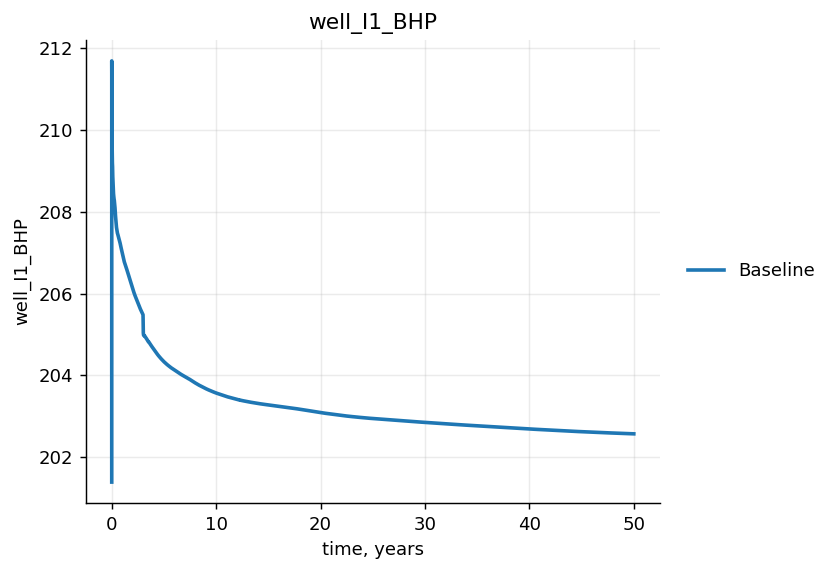

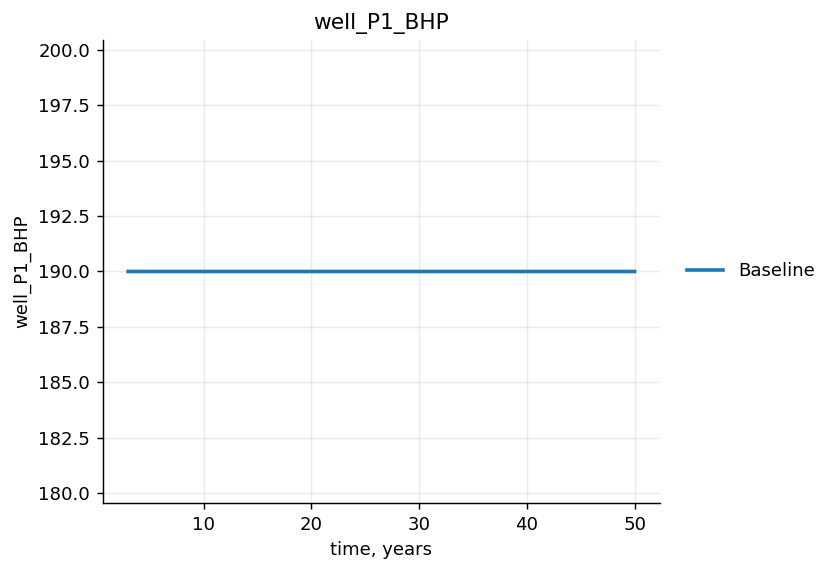

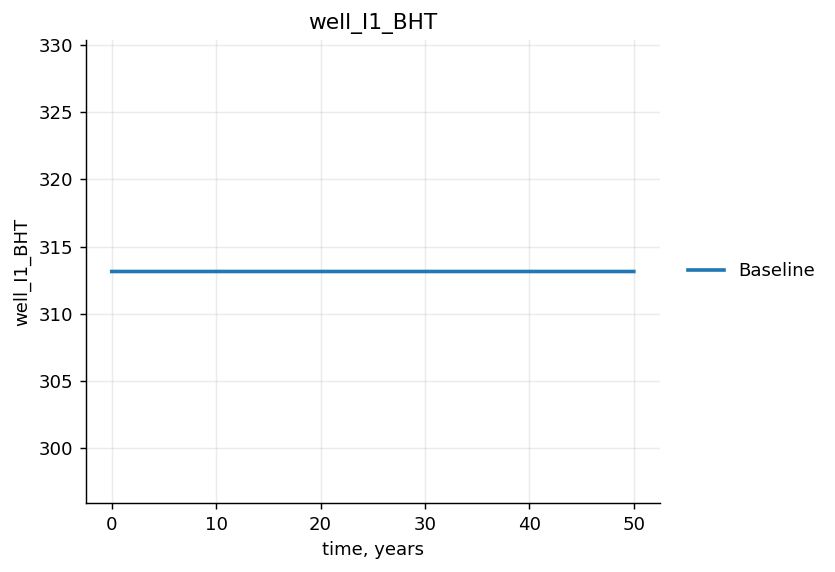

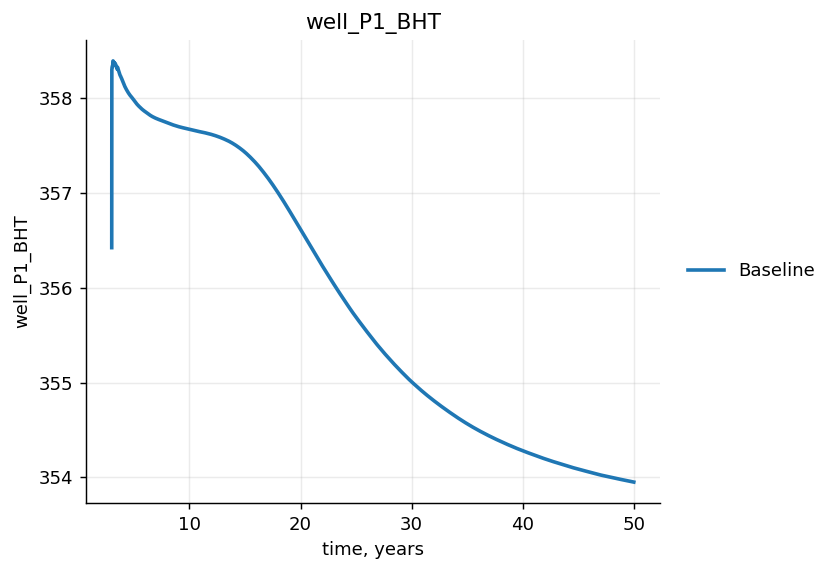

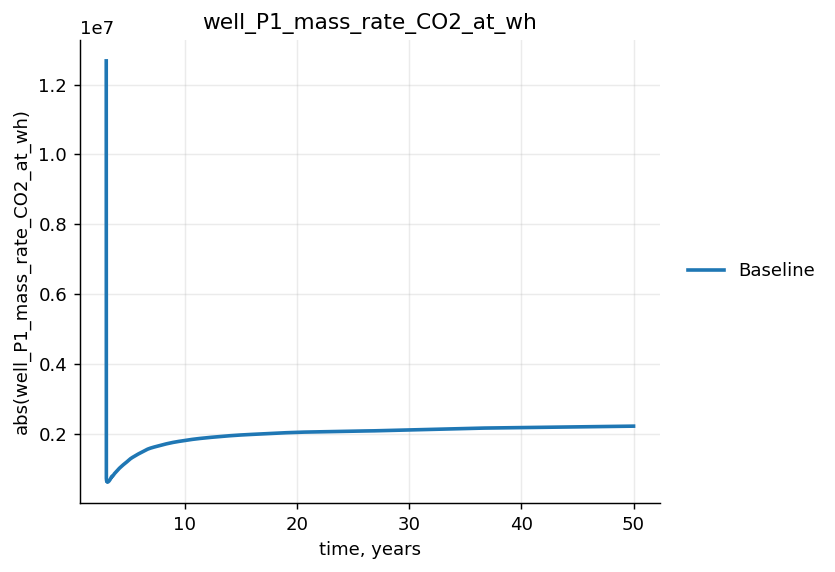

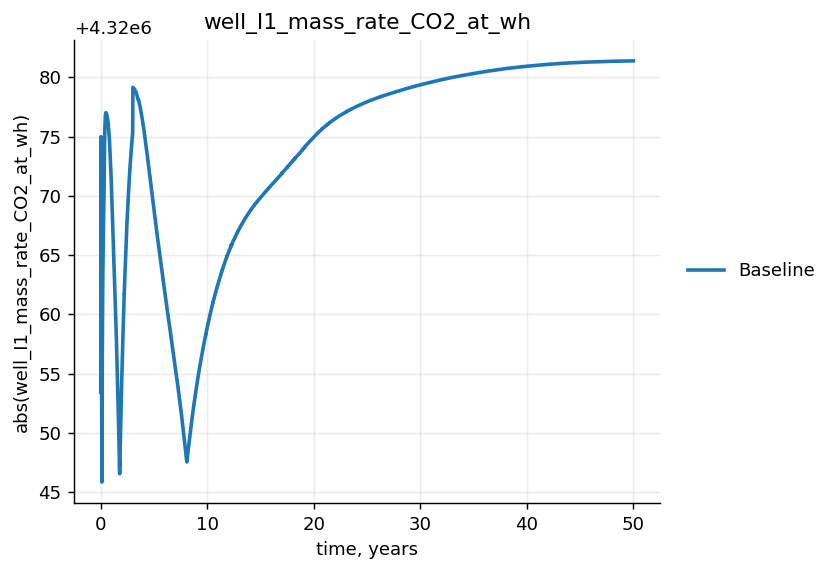

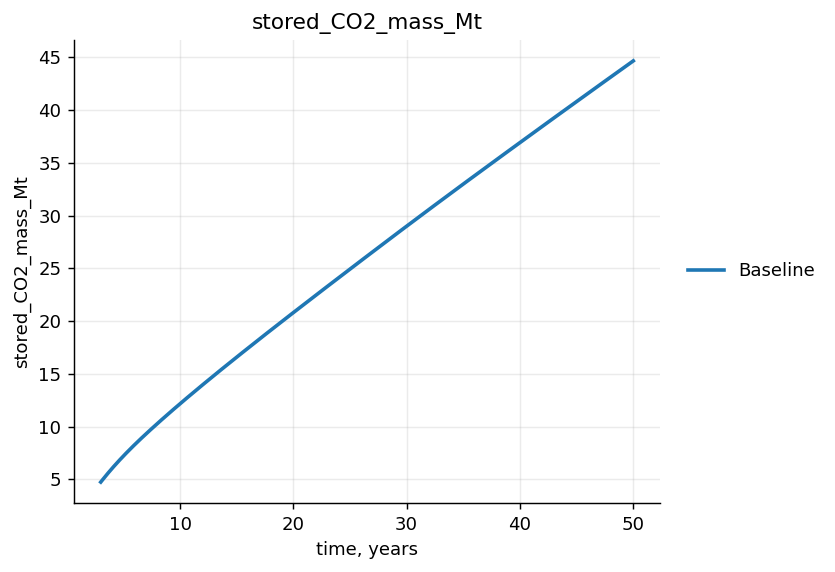

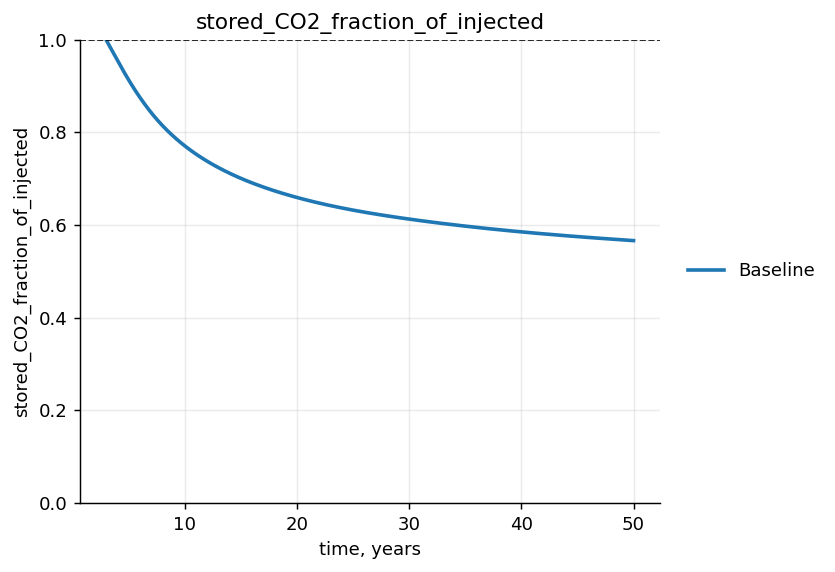

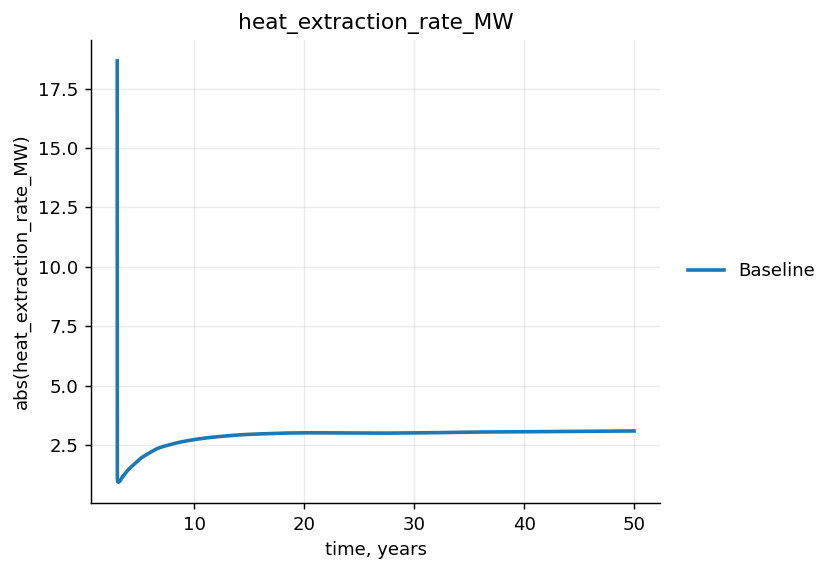

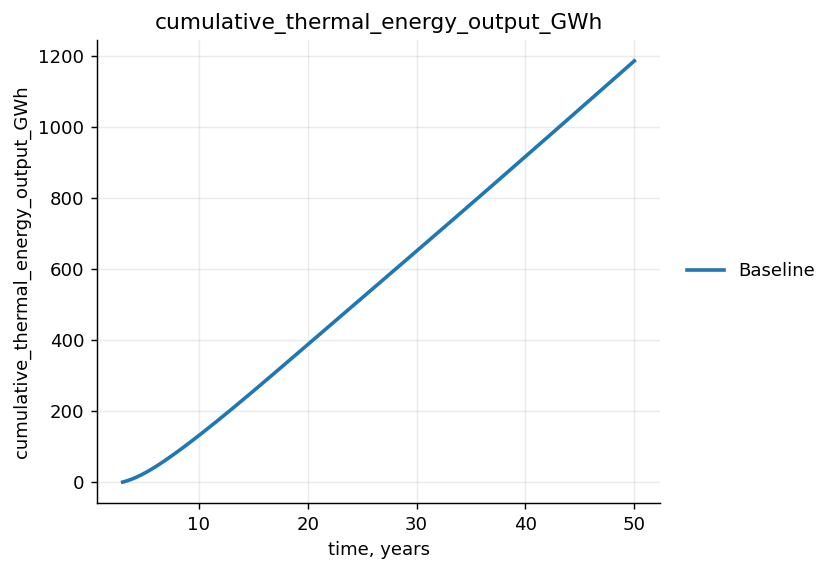

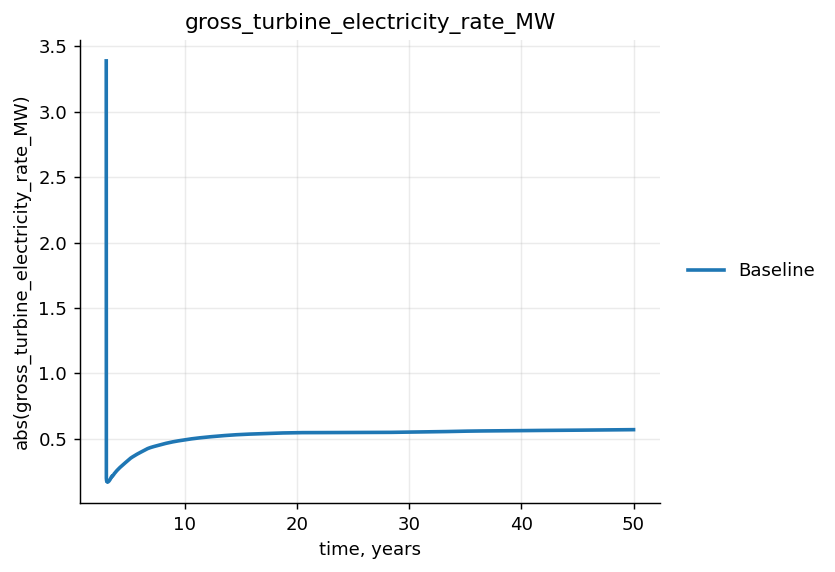

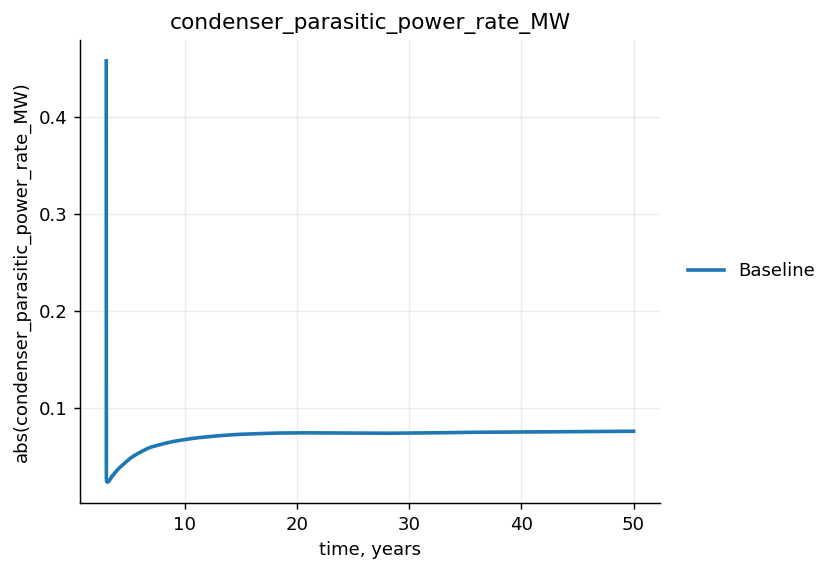

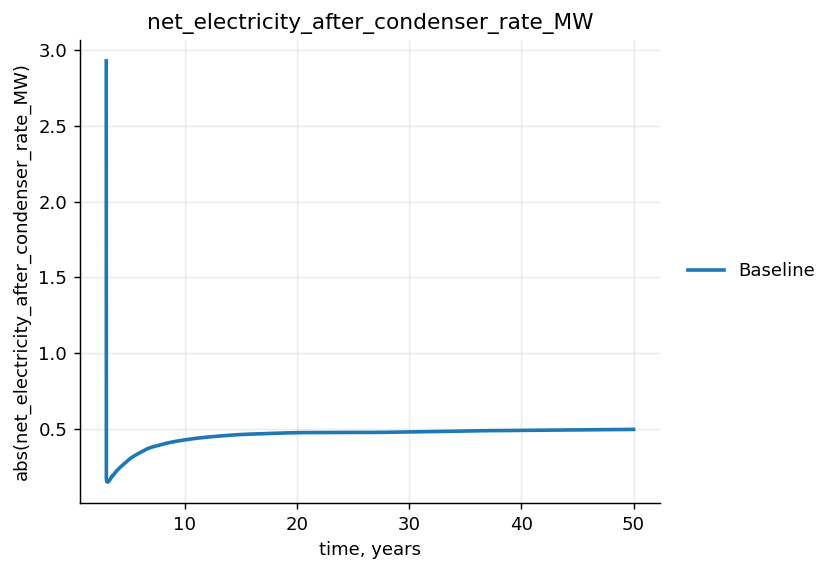

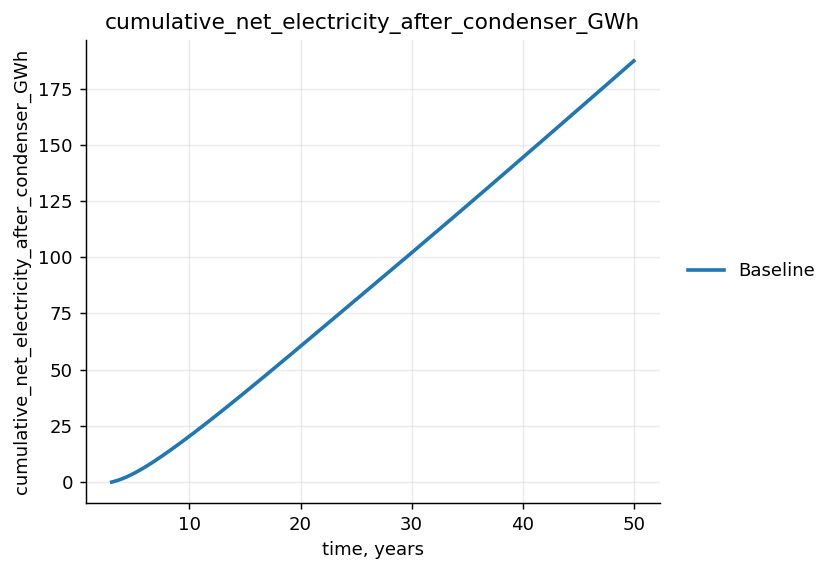

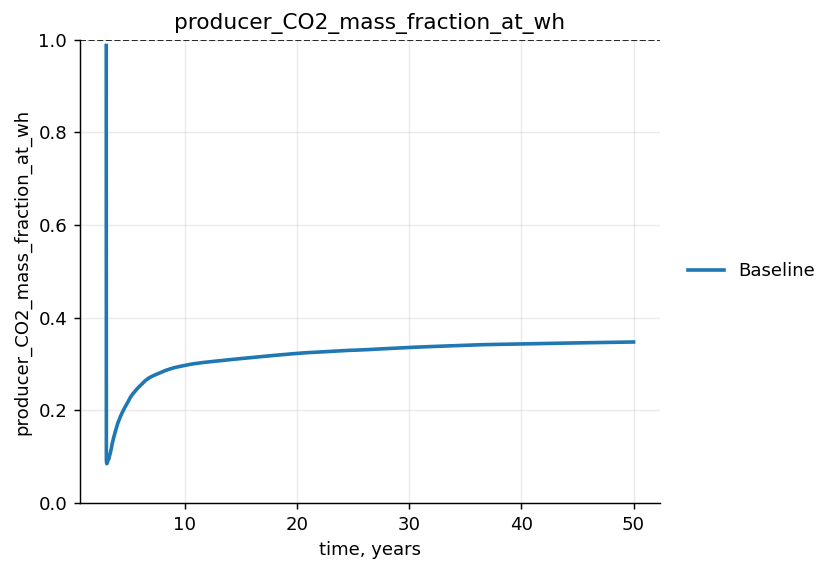

In [11]:
INCLUDE_CO2_H2O_RATIO = True
def plot_case_curve(cases, comparison, time_scale=1.0, time_label="time"):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    for label, case in cases.items():
        column = comparison_column(comparison, label)
        x, y = get_series(case, column)
        xs, ys = smooth_xy(x / time_scale, y)
        ax.plot(xs, ys, linewidth=2.0, label=label)
    ax.set_title(comparison_name(comparison))
    ax.set_xlabel(time_label)
    ax.set_ylabel(display_variable_name(comparison_name(comparison)))
    apply_variable_axis_format(ax, comparison_name(comparison))
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
    fig.tight_layout(rect=(0, 0, 0.82, 1))
    return fig


def plot_case_curves(cases, comparisons, time_scale=1.0, time_label="time"):
    figures = {}
    for comparison in comparisons:
        name = comparison_name(comparison)
        figures[name] = plot_case_curve(cases, comparison, time_scale, time_label)
        plt.show()
    return figures


case_curve_figures = plot_case_curves(cases, comparisons, TIME_SCALE, TIME_LABEL)


## Difference Against Base Case

In [5]:
def plot_difference(cases, comparison, base_label=BASE_LABEL, time_scale=1.0, time_label="time"):
    this_base_label = comparison_base_label(comparison, base_label)
    grid, aligned, summary = compare_variable(cases, comparison, this_base_label)
    base = aligned[this_base_label]

    fig, ax = plt.subplots(figsize=(8, 4.5))
    for label, y in aligned.items():
        if label == this_base_label:
            continue
        xs, ys = smooth_xy(grid / time_scale, y - base)
        ax.plot(xs, ys, linewidth=2.0, label=f"{label} - {this_base_label}")
    ax.axhline(0.0, color="black", linewidth=0.9)
    ax.set_title(f"Difference: {comparison_name(comparison)}")
    ax.set_xlabel(time_label)
    ax.set_ylabel(f"{display_variable_name(comparison_name(comparison))} difference")
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
    fig.tight_layout(rect=(0, 0, 0.82, 1))
    return fig, summary


def plot_differences(cases, comparisons, base_label=BASE_LABEL, time_scale=1.0, time_label="time"):
    figures = {}
    stats = []
    for comparison in comparisons:
        name = comparison_name(comparison)
        fig, summary = plot_difference(cases, comparison, base_label, time_scale, time_label)
        figures[name] = fig
        stats.append(summary)
        plt.show()
    return figures, pd.concat(stats, ignore_index=True)


difference_figures, stats_df = plot_differences(cases, comparisons, BASE_LABEL, TIME_SCALE, TIME_LABEL)
display(stats_df)


KeyError: 'Fine'

## Overlay One Variable With Difference

Set `FOCUS_COMPARISON` to either an item from `comparisons` or an integer index.


In [ ]:
FOCUS_COMPARISON = -1

focus = comparisons[FOCUS_COMPARISON] if isinstance(FOCUS_COMPARISON, int) else FOCUS_COMPARISON
focus_base_label = comparison_base_label(focus, BASE_LABEL)
grid, aligned, summary = compare_variable(cases, focus, focus_base_label)
base = aligned[focus_base_label]

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
for label, case in cases.items():
    column = comparison_column(focus, label)
    x, y = get_series(case, column)
    xs, ys = smooth_xy(x / TIME_SCALE, y)
    axes[0].plot(xs, ys, linewidth=2.0, label=label)
for label, y in aligned.items():
    if label == focus_base_label:
        continue
    xs, ys = smooth_xy(grid / TIME_SCALE, y - base)
    axes[1].plot(xs, ys, linewidth=2.0, label=f"{label} - {focus_base_label}")
axes[1].axhline(0.0, color="black", linewidth=0.9)
axes[0].set_title(comparison_name(focus))
axes[0].set_ylabel(display_variable_name(comparison_name(focus)))
apply_variable_axis_format(axes[0], comparison_name(focus))
axes[0].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
axes[1].set_xlabel(TIME_LABEL)
axes[1].set_ylabel("difference")
axes[1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
fig.tight_layout(rect=(0, 0, 0.82, 1))
display(summary)


## CO2 Injection Temperature From CoolProp

This block estimates the CO2 temperature at reservoir pressure from a known liquid-CO2 surface state. Because the initial condition can be close to the saturation boundary, the surface entropy calculation explicitly imposes the liquid branch in CoolProp. The path below is still an ideal isentropic endpoint calculation, not a full wellbore heat-transfer model.


In [ ]:
# ===== CO2 injection temperature estimate =====
# Goal: liquid CO2 surface pressure + surface temperature + reservoir pressure
#       -> ideal isentropic endpoint temperature at reservoir pressure.
# This is not a full wellbore temperature model; it neglects depth, heat exchange, friction, and flow rate.
# Units: pressure in bar, temperature in K.
SURFACE_PRESSURE_BAR = 60.0
SURFACE_TEMPERATURE_K = 295.15
RESERVOIR_PRESSURE_BAR = 50.5
CO2_FLUID_NAME = "CO2"
IMPOSE_SURFACE_LIQUID_PHASE = True


def require_coolprop():
    if PropsSI is None:
        raise ImportError(
            "CoolProp is required for this block. Install it in the notebook kernel with: pip install CoolProp"
        )


def co2_phase(pressure_bar, temperature_k):
    require_coolprop()
    return PhaseSI("P", pressure_bar * 1e5, "T", temperature_k, CO2_FLUID_NAME)


def co2_entropy_kj_per_kg_k(pressure_bar, temperature_k, impose_liquid=False):
    require_coolprop()
    pressure_key = "P|liquid" if impose_liquid else "P"
    return PropsSI("S", pressure_key, pressure_bar * 1e5, "T", temperature_k, CO2_FLUID_NAME) / 1000.0


def co2_temperature_from_entropy_and_pressure_k(entropy_kj_per_kg_k, pressure_bar):
    require_coolprop()
    return PropsSI("T", "P", pressure_bar * 1e5, "S", entropy_kj_per_kg_k * 1000.0, CO2_FLUID_NAME)


def reservoir_temperature_from_liquid_surface_condition(
    surface_pressure_bar,
    surface_temperature_k,
    reservoir_pressure_bar,
):
    surface_entropy_kj_per_kg_k = co2_entropy_kj_per_kg_k(
        surface_pressure_bar,
        surface_temperature_k,
        impose_liquid=IMPOSE_SURFACE_LIQUID_PHASE,
    )
    reservoir_temperature_k = co2_temperature_from_entropy_and_pressure_k(
        surface_entropy_kj_per_kg_k,
        reservoir_pressure_bar,
    )
    return reservoir_temperature_k, surface_entropy_kj_per_kg_k


critical_pressure_bar = PropsSI("Pcrit", CO2_FLUID_NAME) / 1e5
critical_temperature_k = PropsSI("Tcrit", CO2_FLUID_NAME)
reservoir_temperature_k, surface_entropy_kj_per_kg_k = reservoir_temperature_from_liquid_surface_condition(
    SURFACE_PRESSURE_BAR,
    SURFACE_TEMPERATURE_K,
    RESERVOIR_PRESSURE_BAR,
)

surface_phase = co2_phase(SURFACE_PRESSURE_BAR, SURFACE_TEMPERATURE_K)
reservoir_phase = co2_phase(RESERVOIR_PRESSURE_BAR, reservoir_temperature_k)

print("Assumption: ideal isentropic path from liquid-CO2 surface condition to reservoir pressure")
print("Interpretation: reversible adiabatic endpoint, not a full wellbore temperature prediction")
print(f"CO2 critical point: Pcrit={critical_pressure_bar:.3f} bar, Tcrit={critical_temperature_k:.2f} K ({critical_temperature_k - 273.15:.2f} degC)")
print(f"Surface condition: P={SURFACE_PRESSURE_BAR:.3f} bar, T={SURFACE_TEMPERATURE_K:.2f} K ({SURFACE_TEMPERATURE_K - 273.15:.2f} degC)")
print(f"Surface phase from CoolProp: {surface_phase}")
print(f"Surface entropy branch: {'liquid imposed' if IMPOSE_SURFACE_LIQUID_PHASE else 'automatic'}")
print(f"Conserved entropy: s={surface_entropy_kj_per_kg_k:.6f} kJ/kg/K")
print(f"Reservoir pressure: P={RESERVOIR_PRESSURE_BAR:.3f} bar")
print(
    "Estimated CO2 temperature at reservoir pressure: "
    f"{reservoir_temperature_k:.2f} K ({reservoir_temperature_k - 273.15:.2f} degC)"
)
print(f"Reservoir-pressure endpoint phase from CoolProp: {reservoir_phase}")


## CO2 Injection Temperature From CoolProp: Isenthalpic Path

This block uses the same surface CO2 condition and reservoir pressure as the isentropic block above, but conserves enthalpy instead of entropy. This represents an ideal throttling/Joule--Thomson endpoint, not a full wellbore heat-transfer model.


In [ ]:
# ===== CO2 isenthalpic injection temperature estimate =====
# Goal: liquid CO2 surface pressure + surface temperature + reservoir pressure
#       -> ideal isenthalpic endpoint temperature at reservoir pressure.
# This represents a throttling/Joule-Thomson endpoint and neglects depth, heat exchange, friction, and flow rate.
# It reuses SURFACE_PRESSURE_BAR, SURFACE_TEMPERATURE_K, RESERVOIR_PRESSURE_BAR,
# CO2_FLUID_NAME, IMPOSE_SURFACE_LIQUID_PHASE, require_coolprop(), and co2_phase()
# from the isentropic block above.


def co2_enthalpy_for_injection_temperature_kj_per_kg(pressure_bar, temperature_k, impose_liquid=False):
    require_coolprop()
    pressure_key = "P|liquid" if impose_liquid else "P"
    return PropsSI("H", pressure_key, pressure_bar * 1e5, "T", temperature_k, CO2_FLUID_NAME) / 1000.0


def co2_temperature_from_enthalpy_and_pressure_k(enthalpy_kj_per_kg, pressure_bar):
    require_coolprop()
    return PropsSI("T", "P", pressure_bar * 1e5, "H", enthalpy_kj_per_kg * 1000.0, CO2_FLUID_NAME)


def reservoir_temperature_from_isenthalpic_surface_condition(
    surface_pressure_bar,
    surface_temperature_k,
    reservoir_pressure_bar,
):
    surface_enthalpy_kj_per_kg = co2_enthalpy_for_injection_temperature_kj_per_kg(
        surface_pressure_bar,
        surface_temperature_k,
        impose_liquid=IMPOSE_SURFACE_LIQUID_PHASE,
    )
    reservoir_temperature_k = co2_temperature_from_enthalpy_and_pressure_k(
        surface_enthalpy_kj_per_kg,
        reservoir_pressure_bar,
    )
    return reservoir_temperature_k, surface_enthalpy_kj_per_kg


reservoir_temperature_isenthalpic_k, surface_enthalpy_kj_per_kg = reservoir_temperature_from_isenthalpic_surface_condition(
    SURFACE_PRESSURE_BAR,
    SURFACE_TEMPERATURE_K,
    RESERVOIR_PRESSURE_BAR,
)

surface_phase_h = co2_phase(SURFACE_PRESSURE_BAR, SURFACE_TEMPERATURE_K)
reservoir_phase_h = co2_phase(RESERVOIR_PRESSURE_BAR, reservoir_temperature_isenthalpic_k)

print("Assumption: ideal isenthalpic path from liquid-CO2 surface condition to reservoir pressure")
print("Interpretation: throttling/Joule-Thomson endpoint, not a full wellbore temperature prediction")
print(f"Surface condition: P={SURFACE_PRESSURE_BAR:.3f} bar, T={SURFACE_TEMPERATURE_K:.2f} K ({SURFACE_TEMPERATURE_K - 273.15:.2f} degC)")
print(f"Surface phase from CoolProp: {surface_phase_h}")
print(f"Surface enthalpy branch: {'liquid imposed' if IMPOSE_SURFACE_LIQUID_PHASE else 'automatic'}")
print(f"Conserved enthalpy: h={surface_enthalpy_kj_per_kg:.6f} kJ/kg")
print(f"Reservoir pressure: P={RESERVOIR_PRESSURE_BAR:.3f} bar")
print(
    "Estimated CO2 temperature at reservoir pressure: "
    f"{reservoir_temperature_isenthalpic_k:.2f} K ({reservoir_temperature_isenthalpic_k - 273.15:.2f} degC)"
)
print(f"Reservoir-pressure endpoint phase from CoolProp: {reservoir_phase_h}")


## P90/P50/P10 Across Realizations

读取 `PERM*_ECL/well_time_data.xlsx`，复用上面已有的 `add_heat_extraction_rate(...)` 计算 Q，然后按最终时刻的注入压力选取并标注 P90/P50/P10 realization。

In [ ]:
# ===== Realization ensemble Q plot =====
REALIZATION_RESULTS_ROOT = Path(r"E:\\100 realizations\\results_closed_83c")
REALIZATION_GLOB = "PERM*_ECL"
REALIZATION_EXCEL_NAME = "well_time_data.xlsx"
REALIZATION_SKIP_INITIAL_TIME_STEPS = 20

REALIZATION_VARIABLES = [
    "well_I1_BHP",
    "well_P1_BHT",
    "well_P1_mass_rate_CO2_at_wh",
]

# Select P90/P50/P10 by the final injection pressure.
# P90 is the realization closest to the 90th percentile of final I1 BHP.
PERCENTILE_METRIC_COLUMN = "well_I1_BHP"

REALIZATION_OUTPUT_FIGURE = REALIZATION_RESULTS_ROOT / "injection_pressure_realizations_P90_P50_P10.png"
REALIZATION_VARIABLES_OUTPUT_FIGURE = REALIZATION_RESULTS_ROOT / "realization_variables_P90_P50_P10.png"


def realization_excel_specs(results_root, realization_glob="PERM*_ECL", excel_name="well_time_data.xlsx"):
    results_root = Path(results_root)
    specs = []
    for case_dir in sorted(results_root.glob(realization_glob), key=natural_sort_key):
        if not case_dir.is_dir():
            continue
        path = case_dir / excel_name
        if path.exists():
            specs.append({"label": case_dir.name, "path": path, "sheet_name": 0})
    if not specs:
        raise FileNotFoundError(f"No realization Excel files found under {results_root}")
    return specs


def load_realization_q_cases(specs, time_column=None, skip_initial_steps=0):
    cases = {}
    for spec in specs:
        label = spec["label"]
        path = Path(spec["path"])
        df = clean_columns(read_table(path, spec.get("sheet_name", 0)))
        tcol = find_time_column(df, time_column)
        df[tcol] = pd.to_numeric(df[tcol], errors="coerce")
        df = df.dropna(subset=[tcol]).sort_values(tcol).drop_duplicates(subset=[tcol], keep="last")
        skip_count = steps_to_skip(skip_initial_steps, label)
        if skip_count:
            df = df.iloc[skip_count:]
        if df.empty:
            raise ValueError(f"No rows left for {label!r} after skipping {skip_count} initial time steps")
        cases[label] = {"df": df, "time_col": tcol, "path": path}
    return cases


def final_metric_table(cases, metric_column):
    rows = []
    for label, case in cases.items():
        df = case["df"]
        if metric_column not in df.columns:
            raise KeyError(f"{metric_column!r} not found for {label}")
        y = pd.to_numeric(df[metric_column], errors="coerce")
        valid = y[np.isfinite(y)]
        rows.append({
            "realization": label,
            "final_metric": float(valid.iloc[-1]) if len(valid) else np.nan,
            "path": str(case["path"]),
        })
    return pd.DataFrame(rows).sort_values("realization", key=lambda s: s.map(natural_sort_key)).reset_index(drop=True)


def percentile_realizations(metric_df):
    clean = metric_df.dropna(subset=["final_metric"]).copy()
    if clean.empty:
        raise ValueError("No finite final_metric values found")
    percentile_map = {"P90": 90.0, "P50": 50.0, "P10": 10.0}
    rows = []
    values = clean["final_metric"].to_numpy(dtype=float)
    for label, percentile in percentile_map.items():
        target = float(np.nanpercentile(values, percentile))
        idx = (clean["final_metric"] - target).abs().idxmin()
        row = clean.loc[idx]
        rows.append({
            "label": label,
            "percentile": percentile,
            "target_metric": target,
            "realization": row["realization"],
            "realization_metric": float(row["final_metric"]),
        })
    return pd.DataFrame(rows)


def plot_realization_percentiles(cases, percentile_df, metric_column, time_scale=TIME_SCALE, time_label=TIME_LABEL):
    fig, ax = plt.subplots(figsize=(9, 5.5))
    for label, case in cases.items():
        x, y = get_series(case, metric_column)
        xs, ys = smooth_xy(x / time_scale, y)
        ax.plot(xs, ys, color="0.72", linewidth=0.8, alpha=0.55, zorder=1)

    styles = {
        "P90": {"color": "#1f77b4", "linewidth": 2.4},
        "P50": {"color": "#2ca02c", "linewidth": 2.6},
        "P10": {"color": "#d62728", "linewidth": 2.4},
    }
    for _, row in percentile_df.iterrows():
        label = row["label"]
        realization = row["realization"]
        x, y = get_series(cases[realization], metric_column)
        xs, ys = smooth_xy(x / time_scale, y)
        ax.plot(
            xs,
            ys,
            label=f"{label}: {realization} ({row['realization_metric']:.4g})",
            zorder=3,
            **styles[label],
        )
        ax.scatter(xs[-1], ys[-1], color=styles[label]["color"], s=30, zorder=4)
        ax.annotate(
            f"{label}\n{realization}",
            xy=(xs[-1], ys[-1]),
            xytext=(8, 0),
            textcoords="offset points",
            va="center",
            fontsize=9,
            color=styles[label]["color"],
        )

    ax.set_xlabel(time_label)
    ax.set_ylabel(display_variable_name(metric_column))
    ax.set_title(f"{metric_column}: 101 realizations with P90/P50/P10")
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
    fig.tight_layout(rect=(0, 0, 0.82, 1))
    return fig


def plot_realization_variable_grid(cases, variables, percentile_df, time_scale=TIME_SCALE, time_label=TIME_LABEL):
    n = len(variables)
    fig, axes = plt.subplots(n, 1, figsize=(9, max(3.0, 2.8 * n)), squeeze=False)
    styles = {
        "P90": {"color": "#1f77b4", "linewidth": 2.2},
        "P50": {"color": "#2ca02c", "linewidth": 2.4},
        "P10": {"color": "#d62728", "linewidth": 2.2},
    }

    for ax, variable in zip(axes.ravel(), variables):
        for case in cases.values():
            x, y = get_series(case, variable)
            xs, ys = smooth_xy(x / time_scale, y)
            ax.plot(xs, ys, color="0.72", linewidth=0.75, alpha=0.5, zorder=1)

        for _, row in percentile_df.iterrows():
            label = row["label"]
            realization = row["realization"]
            x, y = get_series(cases[realization], variable)
            xs, ys = smooth_xy(x / time_scale, y)
            ax.plot(xs, ys, label=f"{label}: {realization}", zorder=3, **styles[label])

        ax.set_title(display_variable_name(variable))
        ax.set_xlabel(time_label)
        ax.set_ylabel(display_variable_name(variable))
        ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

    fig.tight_layout(rect=(0, 0, 0.82, 1))
    return fig


realization_specs = realization_excel_specs(REALIZATION_RESULTS_ROOT, REALIZATION_GLOB, REALIZATION_EXCEL_NAME)
realization_cases = load_realization_q_cases(realization_specs, TIME_COLUMN, REALIZATION_SKIP_INITIAL_TIME_STEPS)
realization_metric_df = final_metric_table(realization_cases, PERCENTILE_METRIC_COLUMN)
realization_percentile_df = percentile_realizations(realization_metric_df)

display(realization_percentile_df)
fig = plot_realization_percentiles(realization_cases, realization_percentile_df, PERCENTILE_METRIC_COLUMN)
fig.savefig(REALIZATION_OUTPUT_FIGURE, bbox_inches="tight")
fig_vars = plot_realization_variable_grid(realization_cases, REALIZATION_VARIABLES, realization_percentile_df)
fig_vars.savefig(REALIZATION_VARIABLES_OUTPUT_FIGURE, bbox_inches="tight")
print(f"Loaded {len(realization_cases)} realizations")
print(f"Skipped first {REALIZATION_SKIP_INITIAL_TIME_STEPS} time steps per realization")
print(f"Saved figure to: {REALIZATION_OUTPUT_FIGURE}")
print(f"Saved variable comparison figure to: {REALIZATION_VARIABLES_OUTPUT_FIGURE}")


## Sensitivity Analysis Cases

?? 500m/1000m/2000m case list ?? `well_time_data.xlsx`???????? `add_heat_extraction_rate(...)` ?? Q???? depth?horizontal permeability?kv/kh?injection rate ?????????? shallow ?? `S_17C` ???????? 16C??? `SENSITIVITY_SHALLOW_TEMPERATURE`?


In [ ]:

# ===== Sensitivity analysis plots =====
SENSITIVITY_ROOT = Path(r"E:\Thesis results\Pure_CO2_S\bhp control, 83c, 690well_dis")
SENSITIVITY_SHALLOW_TEMPERATURE = "17C"  # "17C" or "16C"
SENSITIVITY_EXCEL_NAME = "well_time_data.xlsx"
SENSITIVITY_SKIP_INITIAL_TIME_STEPS = 20
SENSITIVITY_OUTPUT_DIR = SENSITIVITY_ROOT / "_sensitivity_figures"
SENSITIVITY_SAVE_FIGURES = False

SENSITIVITY_PRODUCER_MASS_RATE_COLUMN = "producer_mass_rate_at_wh"
SENSITIVITY_PRODUCER_H2O_MASS_RATE_COLUMN = "producer_H2O_mass_rate_at_wh"
SENSITIVITY_INCLUDE_CO2_H2O_RATIO = False
SENSITIVITY_CO2_H2O_RATIO_COLUMN = globals().get(
    "CO2_H2O_RATIO_COLUMN",
    "producer_CO2_mass_fraction_at_wh",
)

SENSITIVITY_VARIABLES = [
    HEAT_EXTRACTION_COLUMN,
    CUMULATIVE_ENERGY_OUTPUT_GWH_COLUMN,
    "well_I1_BHP",
    "well_P1_BHT",
    SENSITIVITY_PRODUCER_MASS_RATE_COLUMN,
]
if SENSITIVITY_INCLUDE_CO2_H2O_RATIO:
    SENSITIVITY_VARIABLES.append(SENSITIVITY_CO2_H2O_RATIO_COLUMN)

SENSITIVITY_CASE_METADATA = [
    # Shallow, 500 m
    {"case": "S-01", "depth_model": "Shallow", "depth_m": 500, "purpose": "Baseline", "kh_md": 800, "kvkh": 0.1, "injection_rate": 50, "heterogeneity": "Homogeneous"},
    {"case": "S-02", "depth_model": "Shallow", "depth_m": 500, "purpose": "Heterogeneity", "kh_md": "realization-specific", "kvkh": 0.1, "injection_rate": 50, "heterogeneity": "Realization 78"},
    {"case": "S-03", "depth_model": "Shallow", "depth_m": 500, "purpose": "Heterogeneity", "kh_md": "realization-specific", "kvkh": 0.1, "injection_rate": 50, "heterogeneity": "Realization 85"},
    {"case": "S-04", "depth_model": "Shallow", "depth_m": 500, "purpose": "Heterogeneity", "kh_md": "realization-specific", "kvkh": 0.1, "injection_rate": 50, "heterogeneity": "Realization 66"},
    {"case": "S-05", "depth_model": "Shallow", "depth_m": 500, "purpose": "Injection rate: low", "kh_md": 800, "kvkh": 0.1, "injection_rate": 25, "heterogeneity": "Homogeneous"},
    {"case": "S-06", "depth_model": "Shallow", "depth_m": 500, "purpose": "Injection rate: high", "kh_md": 800, "kvkh": 0.1, "injection_rate": 100, "heterogeneity": "Homogeneous"},
    {"case": "S-07", "depth_model": "Shallow", "depth_m": 500, "purpose": "Vertical connectivity", "kh_md": 800, "kvkh": 1, "injection_rate": 50, "heterogeneity": "Homogeneous"},
    # Middle, 1000 m
    {"case": "M-01", "depth_model": "Middle", "depth_m": 1000, "purpose": "Baseline", "kh_md": 800, "kvkh": 0.1, "injection_rate": 50, "heterogeneity": "Homogeneous"},
    {"case": "M-02", "depth_model": "Middle", "depth_m": 1000, "purpose": "Heterogeneity", "kh_md": "realization-specific", "kvkh": 0.1, "injection_rate": 50, "heterogeneity": "Realization 78"},
    {"case": "M-03", "depth_model": "Middle", "depth_m": 1000, "purpose": "Heterogeneity", "kh_md": "realization-specific", "kvkh": 0.1, "injection_rate": 50, "heterogeneity": "Realization 85"},
    {"case": "M-04", "depth_model": "Middle", "depth_m": 1000, "purpose": "Heterogeneity", "kh_md": "realization-specific", "kvkh": 0.1, "injection_rate": 50, "heterogeneity": "Realization 66"},
    {"case": "M-05", "depth_model": "Middle", "depth_m": 1000, "purpose": "Injection rate: low", "kh_md": 800, "kvkh": 0.1, "injection_rate": 25, "heterogeneity": "Homogeneous"},
    {"case": "M-06", "depth_model": "Middle", "depth_m": 1000, "purpose": "Injection rate: high", "kh_md": 800, "kvkh": 0.1, "injection_rate": 100, "heterogeneity": "Homogeneous"},
    {"case": "M-07", "depth_model": "Middle", "depth_m": 1000, "purpose": "Vertical connectivity", "kh_md": 800, "kvkh": 1, "injection_rate": 50, "heterogeneity": "Homogeneous"},
    # Deep, 2000 m
    {"case": "D-01", "depth_model": "Deep", "depth_m": 2000, "purpose": "Baseline", "kh_md": 800, "kvkh": 0.1, "injection_rate": 50, "heterogeneity": "Homogeneous"},
    {"case": "D-02", "depth_model": "Deep", "depth_m": 2000, "purpose": "Heterogeneity", "kh_md": "realization-specific", "kvkh": 0.1, "injection_rate": 50, "heterogeneity": "Realization 78"},
    {"case": "D-03", "depth_model": "Deep", "depth_m": 2000, "purpose": "Heterogeneity", "kh_md": "realization-specific", "kvkh": 0.1, "injection_rate": 50, "heterogeneity": "Realization 85"},
    {"case": "D-04", "depth_model": "Deep", "depth_m": 2000, "purpose": "Heterogeneity", "kh_md": "realization-specific", "kvkh": 0.1, "injection_rate": 50, "heterogeneity": "Realization 66"},
    {"case": "D-05", "depth_model": "Deep", "depth_m": 2000, "purpose": "Injection rate: low", "kh_md": 800, "kvkh": 0.1, "injection_rate": 25, "heterogeneity": "Homogeneous"},
    {"case": "D-06", "depth_model": "Deep", "depth_m": 2000, "purpose": "Injection rate: high", "kh_md": 800, "kvkh": 0.1, "injection_rate": 100, "heterogeneity": "Homogeneous"},
    {"case": "D-07", "depth_model": "Deep", "depth_m": 2000, "purpose": "Horizontal permeability: low", "kh_md": 200, "kvkh": 0.1, "injection_rate": 50, "heterogeneity": "Homogeneous"},
    {"case": "D-08", "depth_model": "Deep", "depth_m": 2000, "purpose": "Horizontal permeability: medium-low", "kh_md": 400, "kvkh": 0.1, "injection_rate": 50, "heterogeneity": "Homogeneous"},
    {"case": "D-09", "depth_model": "Deep", "depth_m": 2000, "purpose": "Horizontal permeability: high", "kh_md": 1600, "kvkh": 0.1, "injection_rate": 50, "heterogeneity": "Homogeneous"},
    {"case": "D-10", "depth_model": "Deep", "depth_m": 2000, "purpose": "Strong vertical anisotropy", "kh_md": 800, "kvkh": 0.01, "injection_rate": 50, "heterogeneity": "Homogeneous"},
    {"case": "D-11", "depth_model": "Deep", "depth_m": 2000, "purpose": "Isotropic permeability", "kh_md": 800, "kvkh": 1, "injection_rate": 50, "heterogeneity": "Homogeneous"},
]


def sensitivity_case_folder(case_id):
    if case_id.startswith("D-"):
        return SENSITIVITY_ROOT / case_id
    if case_id.startswith("M-"):
        if case_id in {"M-01", "M-05", "M-06", "M-07"}:
            return SENSITIVITY_ROOT / f"{case_id}-single_phase"
        return SENSITIVITY_ROOT / f"{case_id}_single_phase"
    if case_id.startswith("S-"):
        if SENSITIVITY_SHALLOW_TEMPERATURE.upper() == "17C":
            return SENSITIVITY_ROOT / "S_17C" / f"{case_id}_single_phase_17C"
        if case_id == "S-01":
            candidate = SENSITIVITY_ROOT / "S_16c" / "S-01_single_phase"
            return candidate if candidate.exists() else SENSITIVITY_ROOT / "S_16c" / "S-01_16c"
        return SENSITIVITY_ROOT / "S_16c" / f"{case_id}_single_phase"
    raise ValueError(f"Unsupported case ID: {case_id}")


def sensitivity_label(meta, label_mode="case"):
    case = meta["case"]
    if label_mode == "depth":
        return f"{case}: {meta['depth_m']} m"
    if label_mode == "kh":
        return f"{case}: kh={meta['kh_md']} mD"
    if label_mode == "kvkh":
        return f"{case}: kv/kh={meta['kvkh']}"
    if label_mode == "rate":
        return f"{case}: rate={meta['injection_rate']}"
    if label_mode == "heterogeneity":
        return f"{case}: {meta['heterogeneity']}"
    return f"{case}: {meta['purpose']}"


def sensitivity_excel_specs(case_ids, label_mode="case", require_existing=True):
    metadata = {meta["case"]: meta for meta in SENSITIVITY_CASE_METADATA}
    specs = []
    missing = []
    for case_id in case_ids:
        meta = metadata[case_id]
        case_dir = sensitivity_case_folder(case_id)
        path = case_dir / SENSITIVITY_EXCEL_NAME
        if not path.exists():
            missing.append(path)
            if require_existing:
                continue
        specs.append({
            "label": sensitivity_label(meta, label_mode),
            "path": path,
            "sheet_name": 0,
            **meta,
        })
    if missing:
        print("Missing sensitivity files:")
        for path in missing:
            print("  ", path)
    if not specs:
        raise FileNotFoundError("No sensitivity files found for selected case IDs")
    return specs


SENSITIVITY_PHASE_FALLBACKS = ("LCO2", "CO2_rich")


def sensitivity_phase_name(case_id):
    # Preferred rule for current depth-comparison outputs: shallow S cases use LCO2; middle/deep use CO2_rich.
    return "LCO2" if case_id.startswith("S-") else "CO2_rich"


def resolve_sensitivity_phase(df, case_id, path):
    preferred = sensitivity_phase_name(case_id)
    phases = [preferred] + [phase for phase in SENSITIVITY_PHASE_FALLBACKS if phase != preferred]
    for phase in phases:
        producer_mass_col = f"well_P1_mass_rate_{phase}_at_wh"
        if producer_mass_col in df.columns:
            if phase != preferred:
                print(f"Using {phase} mass-rate column for {case_id} because {preferred} is not present: {path}")
            return phase
    available_mass_cols = [col for col in df.columns if "mass_rate" in col]
    raise KeyError(
        f"No supported producer mass-rate column found in {Path(path).name} for {case_id}. "
        f"Tried phases: {phases}. Available mass-rate columns: {available_mass_cols}"
    )


def add_sensitivity_standard_columns(df, path, phase_name):
    df = df.copy()
    producer_mass_col = f"well_P1_mass_rate_{phase_name}_at_wh"
    injector_mass_col = f"well_I1_mass_rate_{phase_name}_at_wh"
    required = [
        producer_mass_col,
        PRODUCER_PRESSURE_COLUMN,
        PRODUCER_TEMPERATURE_COLUMN,
    ]
    try:
        require_columns(df, required, path)
    except KeyError as exc:
        available_mass_cols = [col for col in df.columns if "mass_rate" in col]
        raise KeyError(f"{exc}. Available mass-rate columns: {available_mass_cols}") from exc
    df[SENSITIVITY_PRODUCER_MASS_RATE_COLUMN] = pd.to_numeric(df[producer_mass_col], errors="coerce")
    if injector_mass_col in df.columns:
        df["injector_mass_rate_at_wh"] = pd.to_numeric(df[injector_mass_col], errors="coerce")
    h2o_mass_col = first_existing_column(df, [
        "well_P1_mass_rate_H2O_at_wh",
        "well_P1_mass_rate_aqueous_at_wh",
    ])
    if h2o_mass_col is not None:
        df[SENSITIVITY_PRODUCER_H2O_MASS_RATE_COLUMN] = pd.to_numeric(df[h2o_mass_col], errors="coerce")
    if SENSITIVITY_INCLUDE_CO2_H2O_RATIO:
        df = add_co2_h2o_mass_rate_ratio(df, path, out_col=SENSITIVITY_CO2_H2O_RATIO_COLUMN)
    producer_mass_rate_kg_per_day = np.abs(pd.to_numeric(df[producer_mass_col], errors="coerce"))
    h_produced = co2_enthalpy_kj_per_kg(
        pd.to_numeric(df[PRODUCER_PRESSURE_COLUMN], errors="coerce"),
        pd.to_numeric(df[PRODUCER_TEMPERATURE_COLUMN], errors="coerce"),
    )
    h_injected = co2_surface_reference_enthalpy_kj_per_kg()
    df[HEAT_EXTRACTION_COLUMN] = producer_mass_rate_kg_per_day * (h_produced - h_injected) / 86400.0 / 1000.0
    df[f"{HEAT_EXTRACTION_COLUMN}_h_produced_kJ_per_kg"] = h_produced
    df[f"{HEAT_EXTRACTION_COLUMN}_h_injected_kJ_per_kg"] = h_injected
    df["sensitivity_phase_name"] = phase_name
    df["sensitivity_source_mass_rate_column"] = producer_mass_col
    df["sensitivity_source_h2o_mass_rate_column"] = h2o_mass_col
    return df


def load_sensitivity_cases(case_ids, label_mode="case"):
    specs = sensitivity_excel_specs(case_ids, label_mode=label_mode)
    cases = {}
    for spec in specs:
        label = spec["label"]
        path = Path(spec["path"])
        df = clean_columns(read_table(path, spec.get("sheet_name", 0)))
        tcol = find_time_column(df, TIME_COLUMN)
        df[tcol] = pd.to_numeric(df[tcol], errors="coerce")
        df = df.dropna(subset=[tcol]).sort_values(tcol).drop_duplicates(subset=[tcol], keep="last")
        skip_count = steps_to_skip(SENSITIVITY_SKIP_INITIAL_TIME_STEPS, label)
        if skip_count:
            df = df.iloc[skip_count:]
        if df.empty:
            raise ValueError(f"No rows left for {label!r} after skipping {skip_count} initial time steps")
        phase_name = resolve_sensitivity_phase(df, spec["case"], path)
        df = add_sensitivity_standard_columns(df, path, phase_name)
        df = add_cumulative_energy_output(df, tcol)
        cases[label] = {"df": df, "time_col": tcol, "path": path, "phase_name": phase_name, "metadata": spec}
    return cases


def safe_filename(text):
    return "".join(ch if ch.isalnum() or ch in "-_" else "_" for ch in str(text)).strip("_")


def plot_sensitivity_group(group_name, case_ids, variables=SENSITIVITY_VARIABLES, label_mode="case"):
    group_cases = load_sensitivity_cases(case_ids, label_mode=label_mode)
    n = len(variables)
    fig, axes = plt.subplots(n, 1, figsize=(9.5, max(3.0, 2.7 * n)), squeeze=False)
    for ax, variable in zip(axes.ravel(), variables):
        for label, case in group_cases.items():
            x, y = get_series(case, variable)
            xs, ys = smooth_xy(x / TIME_SCALE, y)
            ax.plot(xs, ys, linewidth=2.0, label=label)
        ax.set_title(display_variable_name(variable))
        ax.set_xlabel(TIME_LABEL)
        ax.set_ylabel(display_variable_name(variable))
        apply_variable_axis_format(ax, variable)
        ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
    fig.suptitle(group_name, y=1.0, fontsize=13)
    fig.tight_layout(rect=(0, 0, 0.78, 0.98))
    return fig, group_cases


def save_sensitivity_figure(group_name, fig, output_dir=SENSITIVITY_OUTPUT_DIR):
    Path(output_dir).mkdir(parents=True, exist_ok=True)
    fig.savefig(Path(output_dir) / f"{safe_filename(group_name)}.png", bbox_inches="tight")


SENSITIVITY_GROUPS = {
    # Cross-depth comparisons. Each group keeps geology/control settings matched and changes depth only.
    "Depth comparison - baseline cases": (["S-01", "M-01", "D-01"], "depth"),
    "Depth comparison - low injection rate": (["S-05", "M-05", "D-05"], "depth"),
    "Depth comparison - high injection rate": (["S-06", "M-06", "D-06"], "depth"),
    "Depth comparison - heterogeneity R78": (["S-02", "M-02", "D-02"], "depth"),
    "Depth comparison - heterogeneity R85": (["S-03", "M-03", "D-03"], "depth"),
    "Depth comparison - heterogeneity R66": (["S-04", "M-04", "D-04"], "depth"),
    "Depth comparison - isotropic kvkh": (["S-07", "M-07", "D-11"], "depth"),
    # Original within-depth sensitivity comparisons.
    "Horizontal permeability sensitivity - deep cases": (["D-07", "D-08", "D-01", "D-09"], "kh"),
    "kvkh sensitivity - shallow cases": (["S-01", "S-07"], "kvkh"),
    "kvkh sensitivity - middle cases": (["M-01", "M-07"], "kvkh"),
    "kvkh sensitivity - deep cases": (["D-10", "D-01", "D-11"], "kvkh"),
    "Injection rate sensitivity - shallow cases": (["S-05", "S-01", "S-06"], "rate"),
    "Injection rate sensitivity - middle cases": (["M-05", "M-01", "M-06"], "rate"),
    "Injection rate sensitivity - deep cases": (["D-05", "D-01", "D-06"], "rate"),
}

sensitivity_figures = {}
sensitivity_loaded_cases = {}
for group_name, (case_ids, label_mode) in SENSITIVITY_GROUPS.items():
    fig, group_cases = plot_sensitivity_group(group_name, case_ids, label_mode=label_mode)
    sensitivity_figures[group_name] = fig
    sensitivity_loaded_cases[group_name] = group_cases
    if SENSITIVITY_SAVE_FIGURES:
        save_sensitivity_figure(group_name, fig)
    plt.show()


In [ ]:
import re
import os
import pandas as pd
import matplotlib.pyplot as plt


def plot_average_res_pressure_from_log(
    log_path,
    save_path=None,
    time_unit="years",
    show=True,
):
    """
    Extract average reservoir pressure from DARTS run.log and plot it.

    Expected log line example:
    Time 16466.50 days, Average reservoir pressure: 204.86 bar

    Parameters
    ----------
    log_path : str
        Path to run.log.
    save_path : str or None
        If given, save the figure to this path.
    time_unit : {"days", "years"}
        Plot time in days or years.
    show : bool
        Whether to show the plot.

    Returns
    -------
    df : pandas.DataFrame
        Columns: time_days, avg_pressure_bar
    """

    pattern = re.compile(
        r"Time\s+([0-9.eE+-]+)\s+days,\s*Average reservoir pressure:\s*([0-9.eE+-]+)\s+bar"
    )

    times = []
    pressures = []

    with open(log_path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            match = pattern.search(line)
            if match:
                times.append(float(match.group(1)))
                pressures.append(float(match.group(2)))

    if len(times) == 0:
        raise ValueError(
            f"No average reservoir pressure records found in {log_path}. "
            "Check whether the log contains lines like: "
            "'Time 16466.50 days, Average reservoir pressure: 204.86 bar'."
        )

    df = pd.DataFrame({
        "time_days": times,
        "avg_pressure_bar": pressures,
    })

    # remove possible duplicated time records, keep the last one
    df = df.drop_duplicates(subset="time_days", keep="last").sort_values("time_days")

    if time_unit == "years":
        x = df["time_days"] / 365.25
        xlabel = "Time [years]"
    elif time_unit == "days":
        x = df["time_days"]
        xlabel = "Time [days]"
    else:
        raise ValueError("time_unit must be either 'days' or 'years'.")

    plt.figure(figsize=(7.5, 4.5), dpi=150)
    plt.plot(x, df["avg_pressure_bar"], linewidth=1.8)
    plt.xlabel(xlabel)
    plt.ylabel("Average reservoir pressure [bar]")
    plt.title("Average Reservoir Pressure")
    plt.grid(True, alpha=0.3)

    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, bbox_inches="tight", dpi=300)

    if show:
        plt.show()
    else:
        plt.close()

    return df

df_avg_p = plot_average_res_pressure_from_log(
    log_path=r"E:\Thesis results\CMG_Repro\multi-seg\run.log",
    save_path="output_mass_rate_control/figures/average_reservoir_pressure.png",
    time_unit="years",
)